# Detection d'objets dans des images aeriennes - DOTA-v1.0

Dans ce projet, je cherche a detecter et classer des objets dans des images aeriennes. Les images viennent du jeu de donnees DOTA-v1.0 et contiennent notamment des avions, des bateaux, des vehicules et des terrains de sport.

Je vais comparer deux modeles : **Faster R-CNN**, utilise avec des boites horizontales, et **YOLO26n-OBB**, qui conserve l'orientation des objets. Une derniere partie etudiera l'effet de la petite taille d'un objet sur sa probabilite d'etre correctement detecte.

Le notebook suit les six questions du sujet, de l'exploration des donnees jusqu'a la conclusion predictive et causale.

- Jeu de donnees : [DOTA-v1.0](https://captain-whu.github.io/DOTA/)
- Page de telechargement : [DOTA Dataset](https://captain-whu.github.io/DOTA/dataset.html)
- Langage utilise : **Python**


In [1]:
from pathlib import Path
import json
import os
import random
import sys

PROJECT_DIR = Path.cwd().resolve()
os.environ["YOLO_CONFIG_DIR"] = str(PROJECT_DIR / ".ultralytics_config")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device_name = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU"

print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Materiel utilise : {device_name}")

Python : 3.14.3
PyTorch : 2.11.0+cu130
Materiel utilise : NVIDIA GeForce RTX 4060


In [2]:
TRAIN_IMAGE_DIR = PROJECT_DIR / "Training Data" / "Images"
TRAIN_LABEL_DIR = PROJECT_DIR / "Training Data" / "LabelTxt"
VAL_IMAGE_DIR = PROJECT_DIR / "Validation Data" / "Images"
VAL_LABEL_DIR = PROJECT_DIR / "Validation Data" / "LabelTxt"
TEST_IMAGE_DIR = PROJECT_DIR / "Testing Images" / "Images"

PREPARED_DIR = PROJECT_DIR / "prepared_data"
RUNS_DIR = PROJECT_DIR / "runs"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "analysis"

# False permet de reutiliser les poids deja presents.
FORCE_TRAINING = False

data_paths = {
    "Images train": TRAIN_IMAGE_DIR,
    "Annotations train": TRAIN_LABEL_DIR,
    "Images validation": VAL_IMAGE_DIR,
    "Annotations validation": VAL_LABEL_DIR,
    "Images test": TEST_IMAGE_DIR,
}

path_check = pd.DataFrame(
    {
        "dossier": list(data_paths),
        "chemin relatif": [str(path.relative_to(PROJECT_DIR)) for path in data_paths.values()],
        "present": [path.exists() for path in data_paths.values()],
    }
)

if not path_check["present"].all():
    raise FileNotFoundError("Un ou plusieurs dossiers DOTA sont absents.")

path_check

,dossier,chemin relatif,present
0,Images train,Training Data\Images,True
1,Annotations train,Training Data\LabelTxt,True
2,Images validation,Validation Data\Images,True
3,Annotations validation,Validation Data\LabelTxt,True
4,Images test,Testing Images\Images,True


## 1. Exploration du jeu de donnees

### 1.1 Nombre d'images et d'annotations

Je commence par charger la liste des fichiers de chaque ensemble pour verifier la taille du jeu de donnees.

In [3]:
train_images = sorted(TRAIN_IMAGE_DIR.glob("*.png"))
train_annotations = sorted(TRAIN_LABEL_DIR.glob("*.txt"))
val_images = sorted(VAL_IMAGE_DIR.glob("*.png"))
val_annotations = sorted(VAL_LABEL_DIR.glob("*.txt"))
test_images = sorted(TEST_IMAGE_DIR.glob("*.png"))

dataset_counts = pd.DataFrame(
    {
        "Ensemble": ["Train", "Validation", "Test"],
        "Images": [len(train_images), len(val_images), len(test_images)],
        "Annotations": [len(train_annotations), len(val_annotations), "Non fournies"],
    }
)

dataset_counts

,Ensemble,Images,Annotations
0,Train,1411,1411
1,Validation,458,458
2,Test,937,Non fournies


Le train est l'ensemble le plus grand avec 1 411 images. La validation contient 458 images et elle permettra de comparer les modeles. Chaque image de train et de validation a un fichier d'annotation. Le test contient 937 images, mais ses annotations ne sont pas fournies.

### 1.2 Categories et nombre d'objets

Dans un fichier DOTA, chaque objet est represente par huit coordonnees, une classe et un indicateur de difficulte. Je charge ces informations pour compter les objets de chaque classe.

In [4]:
def load_dota_annotations(annotation_files, split):
    rows = []

    for annotation_file in annotation_files:
        for line in annotation_file.read_text(encoding="utf-8").splitlines():
            values = line.split()
            if len(values) != 10:
                continue

            row = {"ensemble": split, "image_id": annotation_file.stem}
            for point in range(4):
                row[f"x{point + 1}"] = float(values[2 * point])
                row[f"y{point + 1}"] = float(values[2 * point + 1])
            row["classe"] = values[8]
            row["difficult"] = int(values[9])
            rows.append(row)

    return pd.DataFrame(rows)


train_objects = load_dota_annotations(train_annotations, "Train")
val_objects = load_dota_annotations(val_annotations, "Validation")
objects = pd.concat([train_objects, val_objects], ignore_index=True)

In [5]:
class_counts = (
    objects.groupby(["classe", "ensemble"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Train", "Validation"])
)
class_counts["Total"] = class_counts.sum(axis=1)
class_counts = class_counts.sort_values("Total", ascending=False)
class_counts

ensemble,Train,Validation,Total
classe,,,
ship,28068,8960,37028
small-vehicle,26126,5438,31564
large-vehicle,16969,4387,21356
plane,8055,2531,10586
harbor,5983,2090,8073
storage-tank,5029,2888,7917
tennis-court,2367,760,3127
bridge,2047,464,2511
swimming-pool,1736,440,2176


Les annotations contiennent 98 990 objets en train et 28 853 en validation. Les 15 classes sont presentes dans les deux ensembles. Les bateaux et les petits vehicules sont tres nombreux, alors que les helicopteres sont rares. Le jeu est donc desequilibre et les classes rares pourront etre plus difficiles a apprendre.

### 1.3 Taille des images

Les images DOTA n'ont pas toutes la meme taille. Je lis seulement leur largeur et leur hauteur pour voir cette variation.

In [6]:
def load_image_sizes(image_files, split):
    rows = []
    for image_path in image_files:
        with Image.open(image_path) as image:
            width, height = image.size
        rows.append(
            {
                "ensemble": split,
                "image_id": image_path.stem,
                "largeur": width,
                "hauteur": height,
            }
        )
    return pd.DataFrame(rows)


image_info = pd.concat(
    [
        load_image_sizes(train_images, "Train"),
        load_image_sizes(val_images, "Validation"),
        load_image_sizes(test_images, "Test"),
    ],
    ignore_index=True,
)

image_size_summary = image_info.groupby("ensemble", sort=False).agg(
    Images=("image_id", "size"),
    Largeur_min=("largeur", "min"),
    Largeur_mediane=("largeur", "median"),
    Largeur_max=("largeur", "max"),
    Hauteur_min=("hauteur", "min"),
    Hauteur_mediane=("hauteur", "median"),
    Hauteur_max=("hauteur", "max"),
)

image_size_summary

,Images,Largeur_min,Largeur_mediane,Largeur_max,Hauteur_min,Hauteur_mediane,Hauteur_max
ensemble,,,,,,,
Train,1411,387,1824.0,12029,278,1791.0,8115
Validation,458,353,1871.5,13383,511,1705.5,6759
Test,937,211,1817.0,10240,288,1816.0,7665


La taille mediane est proche de 1 800 x 1 800 pixels, mais certaines images depassent 10 000 pixels de largeur. Les tailles sont donc tres variables. Il faudra decouper les grandes images en tuiles avant l'entrainement.

### 1.4 Surface, orientation et difficulte

Je calcule maintenant la surface de chaque boite et l'angle de son cote le plus long. L'angle est ramene entre 0 et 90 degres.

In [7]:
x = objects[["x1", "x2", "x3", "x4"]].to_numpy()
y = objects[["y1", "y2", "y3", "y4"]].to_numpy()

objects["aire_px2"] = 0.5 * np.abs(
    np.sum(x * np.roll(y, -1, axis=1) - y * np.roll(x, -1, axis=1), axis=1)
)

first_edge = np.column_stack((x[:, 1] - x[:, 0], y[:, 1] - y[:, 0]))
second_edge = np.column_stack((x[:, 2] - x[:, 1], y[:, 2] - y[:, 1]))
use_first = np.linalg.norm(first_edge, axis=1) >= np.linalg.norm(second_edge, axis=1)
main_edge = np.where(use_first[:, None], first_edge, second_edge)
angle = np.degrees(np.arctan2(main_edge[:, 1], main_edge[:, 0])) % 180
objects["orientation_deg"] = np.minimum(angle, 180 - angle)

object_data = objects.merge(
    image_info[image_info["ensemble"] != "Test"],
    on=["ensemble", "image_id"],
    how="left",
    validate="many_to_one",
)
object_data["aire_relative_pct"] = (
    100 * object_data["aire_px2"] / (object_data["largeur"] * object_data["hauteur"])
)

object_summary = object_data.groupby("ensemble", sort=False).agg(
    Objets=("image_id", "size"),
    Aire_mediane_px2=("aire_px2", "median"),
    Aire_95_pct_px2=("aire_px2", lambda values: values.quantile(0.95)),
    Aire_relative_mediane_pct=("aire_relative_pct", "median"),
    Orientation_mediane_deg=("orientation_deg", "median"),
    Difficiles_pct=("difficult", lambda values: 100 * (values > 0).mean()),
).round(3)

object_summary

,Objets,Aire_mediane_px2,Aire_95_pct_px2,Aire_relative_mediane_pct,Orientation_mediane_deg,Difficiles_pct
ensemble,,,,,,
Train,98990,760.0,14558.325,0.018,47.175,5.550
Validation,28853,766.0,17842.000,0.022,52.275,6.616


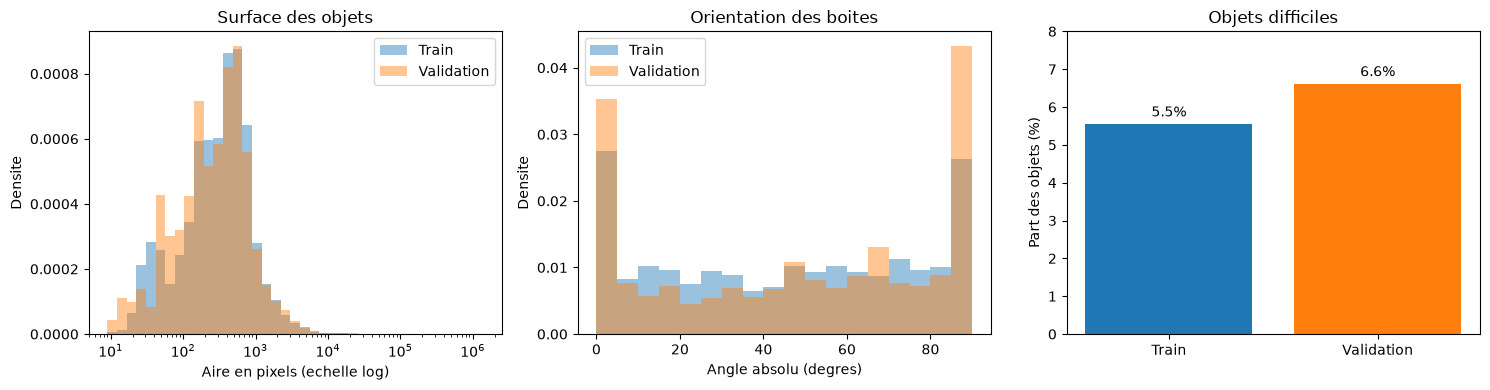

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"Train": "tab:blue", "Validation": "tab:orange"}

positive_areas = object_data.loc[object_data["aire_px2"] > 0, "aire_px2"]
area_bins = np.logspace(
    np.log10(positive_areas.min()), np.log10(positive_areas.max()), 40
)

for split, color in colors.items():
    split_data = object_data[object_data["ensemble"] == split]
    axes[0].hist(
        split_data["aire_px2"], bins=area_bins, density=True,
        alpha=0.45, label=split, color=color
    )
    axes[1].hist(
        split_data["orientation_deg"], bins=np.arange(0, 95, 5),
        density=True, alpha=0.45, label=split, color=color
    )

axes[0].set_xscale("log")
axes[0].set_title("Surface des objets")
axes[0].set_xlabel("Aire en pixels (echelle log)")
axes[0].set_ylabel("Densite")
axes[0].legend()

axes[1].set_title("Orientation des boites")
axes[1].set_xlabel("Angle absolu (degres)")
axes[1].set_ylabel("Densite")
axes[1].legend()

difficult_pct = object_summary["Difficiles_pct"]
axes[2].bar(difficult_pct.index, difficult_pct.values, color=colors.values())
axes[2].set_title("Objets difficiles")
axes[2].set_ylabel("Part des objets (%)")
axes[2].set_ylim(0, 8)
for index, value in enumerate(difficult_pct.values):
    axes[2].text(index, value + 0.2, f"{value:.1f}%", ha="center")

fig.tight_layout()
plt.show()

La surface mediane est proche de 760 pixels carres, mais le 95e percentile depasse 14 000 pixels carres. Il existe donc beaucoup de petits objets et quelques objets beaucoup plus grands. L'angle median est proche de 45 degres ou plus, ce qui montre que les objets ne sont pas seulement horizontaux. Environ 6 % des objets sont marques difficiles.

### 1.5 Visualisation des boites

Je compare les boites orientees DOTA avec leur conversion en boites horizontales sur deux images.

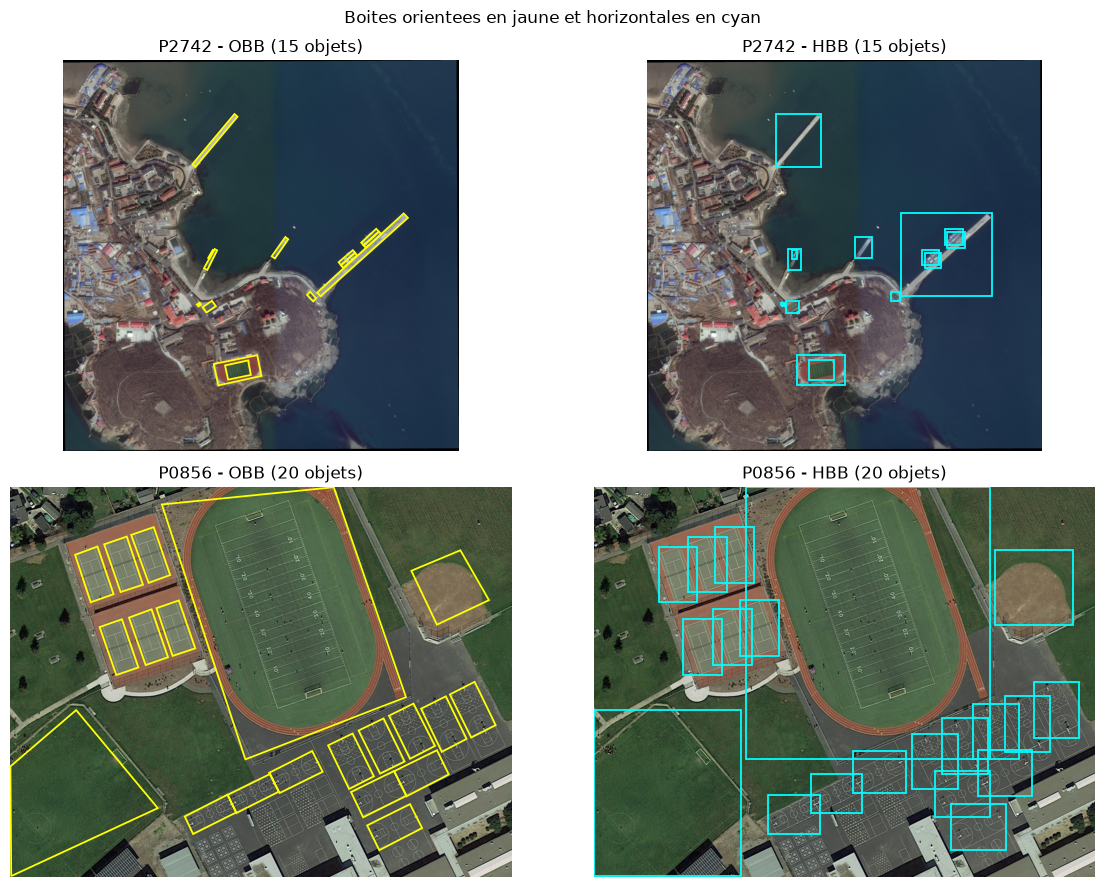

In [9]:
def draw_boxes(ax, image_id, box_type):
    image_path = TRAIN_IMAGE_DIR / f"{image_id}.png"
    with Image.open(image_path) as image:
        ax.imshow(image.convert("RGB"))

    sample_objects = objects[
        (objects["ensemble"] == "Train") & (objects["image_id"] == image_id)
    ]

    for _, row in sample_objects.iterrows():
        points = row[["x1", "y1", "x2", "y2", "x3", "y3", "x4", "y4"]]
        points = points.to_numpy(dtype=float).reshape(4, 2)

        if box_type == "OBB":
            patch = plt.Polygon(points, fill=False, color="yellow", linewidth=1.3)
        else:
            x_min, y_min = points.min(axis=0)
            x_max, y_max = points.max(axis=0)
            patch = plt.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                fill=False, color="cyan", linewidth=1.3
            )
        ax.add_patch(patch)

    ax.set_title(f"{image_id} - {box_type} ({len(sample_objects)} objets)")
    ax.axis("off")


sample_ids = ["P2742", "P0856"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for row_index, image_id in enumerate(sample_ids):
    draw_boxes(axes[row_index, 0], image_id, "OBB")
    draw_boxes(axes[row_index, 1], image_id, "HBB")

fig.suptitle("Boites orientees en jaune et horizontales en cyan")
fig.tight_layout()
plt.show()

Les boites orientees suivent mieux la forme des quais et des terrains inclines. Les boites horizontales contiennent plus d'arriere-plan et peuvent davantage se chevaucher. Cette conversion est necessaire pour Faster R-CNN, mais elle fait perdre une partie de l'information.

### 1.6 Choix des algorithmes

Plusieurs detecteurs peuvent etre utilises sur DOTA : RetinaNet, DETR, Faster R-CNN, YOLO-OBB ou d'autres detecteurs orientes. Pour garder une comparaison claire, je retiens deux modeles :

- **Faster R-CNN avec boites horizontales** : modele de reference en deux etapes. Il est assez simple a utiliser avec torchvision, mais il faut convertir les annotations DOTA.
- **YOLO26n-OBB-1024 avec boites orientees** : modele principal. Il conserve l'angle des objets et convient mieux aux scenes aeriennes.

Les images seront decoupees en tuiles avant l'entrainement. RetinaNet et DETR restent possibles, mais ajouter trop de modeles rendrait le projet plus long. Un arbre causal sera utilise plus tard pour analyser les erreurs; ce n'est pas un detecteur d'objets.

Un classifieur d'image global serait inadapte car il peut reconnaitre une scene sans localiser les objets. Un detecteur standard applique directement aux images geantes serait aussi inadapte sans tuilage.

### 1.7 Risques methodologiques

- **Fuite de donnees** : toutes les tuiles d'une meme image devront rester dans le meme ensemble.
- **Desequilibre des classes** : les classes rares risquent d'etre moins bien apprises que les bateaux ou les vehicules.
- **Conversion des boites** : une boite horizontale perd l'orientation et ajoute parfois beaucoup d'arriere-plan.
- **Prediction et causalite** : une bonne precision ou un bon mAP ne prouve pas qu'une petite taille cause une erreur de detection. Cette question sera traitee separement plus tard.

## 2. Pretraitement des donnees

Les images brutes sont trop grandes pour etre utilisees directement. Le tuilage complet a deja ete execute une fois avec `scripts/prepare_experiment.py`, car il cree plus de 1 000 images. Ce notebook recharge les manifestes produits et refait les controles importants.

### 2.1 Metadonnees des images

Les deux premieres lignes de chaque annotation donnent la source de l'image et sa resolution au sol, appelee GSD.

In [10]:
def load_dota_metadata(annotation_files, split):
    rows = []

    for annotation_file in annotation_files:
        image_source = "unknown"
        gsd = np.nan

        for line in annotation_file.read_text(encoding="utf-8").splitlines()[:2]:
            if line.startswith("imagesource:"):
                image_source = line.split(":", 1)[1].strip()
            elif line.startswith("gsd:"):
                value = line.split(":", 1)[1].strip()
                gsd = np.nan if value == "null" else float(value)

        rows.append(
            {
                "ensemble": split,
                "image_id": annotation_file.stem,
                "image_source": image_source,
                "gsd": gsd,
            }
        )

    return pd.DataFrame(rows)


image_metadata = pd.concat(
    [
        load_dota_metadata(train_annotations, "Train"),
        load_dota_metadata(val_annotations, "Validation"),
    ],
    ignore_index=True,
)

metadata_summary = image_metadata.groupby("ensemble", sort=False).agg(
    Images=("image_id", "size"),
    Sources=("image_source", "nunique"),
    GSD_manquant=("gsd", lambda values: values.isna().sum()),
    GSD_mediane=("gsd", "median"),
).round(3)
source_counts = pd.crosstab(image_metadata["image_source"], image_metadata["ensemble"])

display(metadata_summary)
source_counts

,Images,Sources,GSD_manquant,GSD_mediane
ensemble,,,,
Train,1411,3,1,0.260
Validation,458,3,1,0.258


ensemble,Train,Validation
image_source,,
GF,85,27
GoogleEarth,1209,383
JL,117,48


DOTA contient trois sources : GF, GoogleEarth et JL. GoogleEarth est largement majoritaire. Une seule image par ensemble a un GSD manquant; je garde cette valeur comme manquante au lieu de l'inventer.

### 2.2 Encodage et controle des annotations

Les classes sont converties en nombres. Je cree aussi les boites horizontales, les coordonnees normalisees et quelques variables qui seront reutilisees plus tard.

In [11]:
DOTA_CLASSES = [
    "plane", "ship", "storage-tank", "baseball-diamond",
    "tennis-court", "basketball-court", "ground-track-field",
    "harbor", "bridge", "large-vehicle", "small-vehicle",
    "helicopter", "roundabout", "soccer-ball-field", "swimming-pool",
]
CLASS_TO_ID = {class_name: class_id for class_id, class_name in enumerate(DOTA_CLASSES)}

object_data["class_id"] = object_data["classe"].map(CLASS_TO_ID)
object_data["object_index"] = object_data.groupby(
    ["ensemble", "image_id"]
).cumcount()
object_data["object_id"] = (
    object_data["ensemble"].str.lower() + ":"
    + object_data["image_id"] + ":"
    + object_data["object_index"].astype(str)
)
object_data = object_data.merge(
    image_metadata, on=["ensemble", "image_id"], how="left", validate="many_to_one"
)

x_columns = [f"x{point}" for point in range(1, 5)]
y_columns = [f"y{point}" for point in range(1, 5)]
normalized_columns = []
for point in range(1, 5):
    x_name = f"x{point}_norm"
    y_name = f"y{point}_norm"
    object_data[x_name] = object_data[f"x{point}"] / object_data["largeur"]
    object_data[y_name] = object_data[f"y{point}"] / object_data["hauteur"]
    normalized_columns.extend([x_name, y_name])

object_data["hbb_x_min"] = object_data[x_columns].min(axis=1)
object_data["hbb_y_min"] = object_data[y_columns].min(axis=1)
object_data["hbb_x_max"] = object_data[x_columns].max(axis=1)
object_data["hbb_y_max"] = object_data[y_columns].max(axis=1)
object_data["hbb_width_px"] = object_data["hbb_x_max"] - object_data["hbb_x_min"]
object_data["hbb_height_px"] = object_data["hbb_y_max"] - object_data["hbb_y_min"]

side_1 = np.hypot(object_data["x2"] - object_data["x1"], object_data["y2"] - object_data["y1"])
side_2 = np.hypot(object_data["x3"] - object_data["x2"], object_data["y3"] - object_data["y2"])
object_data["long_side_px"] = np.maximum(side_1, side_2)
object_data["short_side_px"] = np.minimum(side_1, side_2)
object_data["aspect_ratio"] = object_data["long_side_px"] / object_data["short_side_px"]
object_data["center_x_norm"] = object_data[x_columns].mean(axis=1) / object_data["largeur"]
object_data["center_y_norm"] = object_data[y_columns].mean(axis=1) / object_data["hauteur"]
object_data["image_density"] = object_data.groupby(
    ["ensemble", "image_id"]
)["object_id"].transform("size")

normalized_values = object_data[normalized_columns]
object_data["class_unknown"] = object_data["class_id"].isna()
object_data["invalid_area"] = object_data["aire_px2"] <= 0
object_data["invalid_hbb"] = (object_data["hbb_width_px"] <= 0) | (object_data["hbb_height_px"] <= 0)
object_data["outside_image"] = ((normalized_values < 0) | (normalized_values > 1)).any(axis=1)

quality_summary = object_data.groupby("ensemble", sort=False).agg(
    Objets=("object_id", "size"),
    Classes=("class_id", "nunique"),
    Classes_inconnues=("class_unknown", "sum"),
    Aires_invalides=("invalid_area", "sum"),
    HBB_invalides=("invalid_hbb", "sum"),
    Partiellement_hors_image=("outside_image", "sum"),
    Difficiles=("difficult", lambda values: (values > 0).sum()),
)

quality_summary

,Objets,Classes,Classes_inconnues,Aires_invalides,HBB_invalides,Partiellement_hors_image,Difficiles
ensemble,,,,,,,
Train,98990,15,0,0,0,149,5494
Validation,28853,15,0,0,0,22,1909


Les 127 843 objets ont une classe connue et une surface positive. Seulement 171 objets depassent legerement leur image; leurs coordonnees seront coupees au moment du tuilage. Les objets difficiles sont conserves, mais leur indicateur reste disponible pour les analyser separement.

### 2.3 Sous-ensemble experimental

Le jeu complet est trop lourd pour le temps et le materiel disponibles. Je garde 180 images train et 60 images validation. La selection utilise la presence des classes et un type de scene forme par la classe dominante et la densite d'objets.

In [12]:
EXPERIMENT_DIR = PREPARED_DIR / "dota_experiment_v1"
MANIFEST_DIR = EXPERIMENT_DIR / "manifests"
summary_path = EXPERIMENT_DIR / "preparation_summary.json"

required_files = [
    summary_path,
    MANIFEST_DIR / "selected_train_images.csv",
    MANIFEST_DIR / "selected_val_images.csv",
    MANIFEST_DIR / "object_manifest.csv",
    MANIFEST_DIR / "tile_manifest.csv",
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Jeu prepare absent. Executer scripts/prepare_experiment.py avant ce notebook."
    )

preparation_summary = json.loads(summary_path.read_text(encoding="utf-8"))
selected_train = pd.read_csv(MANIFEST_DIR / "selected_train_images.csv")
selected_val = pd.read_csv(MANIFEST_DIR / "selected_val_images.csv")
selected_images = pd.concat([selected_train, selected_val], ignore_index=True)
object_manifest = pd.read_csv(MANIFEST_DIR / "object_manifest.csv")
tile_manifest = pd.read_csv(MANIFEST_DIR / "tile_manifest.csv")

source_overlap = set(selected_train["image_id"]) & set(selected_val["image_id"])
subset_rows = []
for split, selection in [("train", selected_train), ("val", selected_val)]:
    split_objects = object_manifest[object_manifest["split"] == split]
    split_tiles = tile_manifest[tile_manifest["split"] == split]
    subset_rows.append(
        {
            "Ensemble": split,
            "Images_source": len(selection),
            "Strates_scene": selection["scene_stratum"].nunique(),
            "Tuiles": len(split_tiles),
            "Tuiles_sans_objet": int(split_tiles["is_negative_tile"].sum()),
            "Objets_uniques": split_objects["object_id"].nunique(),
            "Classes": split_objects["class_name"].nunique(),
        }
    )

subset_summary = pd.DataFrame(subset_rows)
print(f"Images source presentes dans les deux ensembles : {len(source_overlap)}")
subset_summary

Images source presentes dans les deux ensembles : 0


,Ensemble,Images_source,Strates_scene,Tuiles,Tuiles_sans_objet,Objets_uniques,Classes
0,train,180,36,912,111,4646,15
1,val,60,27,245,33,1646,15


Les 15 classes sont presentes dans train et validation. Aucune image source n'est partagee entre les deux ensembles. Le sous-ensemble reste assez varie, mais il est beaucoup plus realiste a entrainer sur la RTX 4060.

### 2.4 Tuilage et formats OBB/HBB

Les tuiles font 1 024 x 1 024 pixels. Le train utilise un pas de 824 pixels, donc un chevauchement de 200 pixels. La validation utilise un pas de 1 024 pixels. Un objet est garde si au moins 70 % de sa surface reste dans la tuile et si son plus petit cote mesure au moins 2 pixels. Les fragments ambigus entre 20 % et 70 % font retirer la tuile. Environ 15 % des tuiles sans objet sont gardees comme exemples negatifs.

Pour YOLO-OBB, les quatre points sont normalises entre 0 et 1. Pour Faster R-CNN, la meme boite est convertie en `[x_min, y_min, x_max, y_max]`.

In [13]:
tile_x_columns = [f"tile_x{point}" for point in range(1, 5)]
tile_y_columns = [f"tile_y{point}" for point in range(1, 5)]
obb_columns = []

for point in range(1, 5):
    x_name = f"obb_x{point}_norm"
    y_name = f"obb_y{point}_norm"
    object_manifest[x_name] = object_manifest[f"tile_x{point}"] / object_manifest["tile_size"]
    object_manifest[y_name] = object_manifest[f"tile_y{point}"] / object_manifest["tile_size"]
    obb_columns.extend([x_name, y_name])

object_manifest["hbb_x_min"] = object_manifest[tile_x_columns].min(axis=1)
object_manifest["hbb_y_min"] = object_manifest[tile_y_columns].min(axis=1)
object_manifest["hbb_x_max"] = object_manifest[tile_x_columns].max(axis=1)
object_manifest["hbb_y_max"] = object_manifest[tile_y_columns].max(axis=1)

prepared_rows = []
for task in ["obb", "hbb"]:
    for split in ["train", "val"]:
        image_dir = EXPERIMENT_DIR / task / "images" / split
        label_dir = EXPERIMENT_DIR / task / "labels" / split
        prepared_rows.append(
            {
                "Format": task.upper(),
                "Ensemble": split,
                "Images": len(list(image_dir.glob("*.jpg"))),
                "Labels": len(list(label_dir.glob("*.txt"))),
            }
        )
prepared_counts = pd.DataFrame(prepared_rows)

obb_values = object_manifest[obb_columns]
hbb_width = object_manifest["hbb_x_max"] - object_manifest["hbb_x_min"]
hbb_height = object_manifest["hbb_y_max"] - object_manifest["hbb_y_min"]
tile_overlap = set(
    tile_manifest.loc[tile_manifest["split"] == "train", "tile_id"]
) & set(tile_manifest.loc[tile_manifest["split"] == "val", "tile_id"])

format_checks = pd.DataFrame(
    {
        "Controle": [
            "Coordonnees OBB hors [0, 1]",
            "Boites HBB non positives",
            "Fraction conservee hors [0.70, 1]",
            "Tuiles communes train/validation",
        ],
        "Nombre": [
            int(((obb_values < 0) | (obb_values > 1)).any(axis=1).sum()),
            int(((hbb_width <= 0) | (hbb_height <= 0)).sum()),
            int(((object_manifest["retained_fraction"] < 0.70) | (object_manifest["retained_fraction"] > 1)).sum()),
            len(tile_overlap),
        ],
    }
)

display(prepared_counts)
format_checks

,Format,Ensemble,Images,Labels
0,OBB,train,912,912
1,OBB,val,245,245
2,HBB,train,912,912
3,HBB,val,245,245


,Controle,Nombre
0,"Coordonnees OBB hors [0, 1]",0
1,Boites HBB non positives,0
2,"Fraction conservee hors [0.70, 1]",0
3,Tuiles communes train/validation,0


Les images et les labels sont bien alignes dans les deux formats. Les coordonnees OBB restent dans l'intervalle attendu et toutes les boites HBB ont une taille positive. Faster R-CNN lira les colonnes `[x_min, y_min, x_max, y_max]` du manifeste. Les deux modeles utiliseront donc les memes tuiles et les memes objets.

### 2.5 Variables derivees et table d'analyse

Le chevauchement du train peut placer un meme objet dans plusieurs tuiles. Pour l'analyse, je garde une seule ligne par objet original : celle ou la plus grande partie de l'objet est visible.

In [14]:
analysis_objects = (
    object_manifest.sort_values(
        ["object_id", "retained_fraction"], ascending=[True, False]
    )
    .drop_duplicates("object_id")
    .copy()
)
analysis_objects["center_x_norm"] = analysis_objects[["x1", "x2", "x3", "x4"]].mean(axis=1) / analysis_objects["image_width"]
analysis_objects["center_y_norm"] = analysis_objects[["y1", "y2", "y3", "y4"]].mean(axis=1) / analysis_objects["image_height"]
analysis_objects["log_aspect_ratio"] = np.log(analysis_objects["aspect_ratio"])
analysis_objects["image_density"] = analysis_objects.groupby(
    ["split", "image_id"]
)["object_id"].transform("size")
analysis_objects = analysis_objects.merge(
    tile_manifest[["split", "tile_id", "object_count"]].rename(
        columns={"object_count": "tile_density"}
    ),
    on=["split", "tile_id"],
    how="left",
    validate="many_to_one",
)

analysis_columns = [
    "split", "object_id", "image_id", "tile_id", "class_name",
    "difficult", "relative_area_image", "orientation_abs_deg",
    "aspect_ratio", "log_aspect_ratio", "image_density", "tile_density",
    "image_source", "gsd", "center_x_norm", "center_y_norm",
    "retained_fraction",
]
analysis_table = analysis_objects[analysis_columns].copy()
analysis_table["detection_correcte"] = np.nan

analysis_summary = analysis_table.groupby("split", sort=False).agg(
    Objets=("object_id", "size"),
    Images=("image_id", "nunique"),
    Classes=("class_name", "nunique"),
    GSD_manquant=("gsd", lambda values: values.isna().sum()),
)
preview_columns = [
    "split", "image_id", "class_name", "relative_area_image",
    "orientation_abs_deg", "aspect_ratio", "image_density",
    "tile_density", "image_source", "gsd", "detection_correcte",
]

display(analysis_summary)
analysis_table[preview_columns].head()

,Objets,Images,Classes,GSD_manquant
split,,,,
train,4646,161,15,0
val,1646,53,15,0


,split,image_id,class_name,relative_area_image,orientation_abs_deg,aspect_ratio,image_density,tile_density,image_source,gsd,detection_correcte
0,train,P0000,plane,0.000449,12.022277,1.265129,94,6,GoogleEarth,0.146344,NaN
1,train,P0000,large-vehicle,0.000029,24.775141,3.353900,94,2,GoogleEarth,0.146344,NaN
2,train,P0000,small-vehicle,0.000006,25.016893,2.173508,94,18,GoogleEarth,0.146344,NaN
3,train,P0000,large-vehicle,0.000011,80.909723,2.795903,94,7,GoogleEarth,0.146344,NaN
4,train,P0000,small-vehicle,0.000006,79.992020,2.977392,94,12,GoogleEarth,0.146344,NaN


La table contient 6 292 objets uniques. La partie validation contient 1 646 objets venant de 53 images. La colonne `detection_correcte` reste vide pour le moment : elle sera remplie avec les predictions du modele dans la question 3. Cette separation evite de confondre le pretraitement avec le resultat predictif ou causal.

## 3. Modeles predictifs de detection

### 3.1 Tache et protocole

La tache est de localiser chaque objet dans une tuile et de predire sa classe parmi les 15 classes DOTA. Le train sert a apprendre les modeles et la validation sert seulement a mesurer leurs performances.

Je compare une baseline **Faster R-CNN MobileNetV3-FPN** avec boites horizontales et le modele principal **YOLO26n-OBB** avec boites orientees. Les deux utilisent les memes tuiles source. La comparaison utilisera la precision, le rappel, le F1, la mAP, les resultats par classe et quelques predictions visuelles.

In [15]:
FRCNN_IMAGE_SIZE = 640
FRCNN_BATCH_SIZE = 2
FRCNN_EPOCHS = 8
FRCNN_LEARNING_RATE = 0.001
FRCNN_USE_AMP = False

FRCNN_RUN_DIR = RUNS_DIR / "dota_experiment_v1" / "faster_rcnn_mobilenet_hbb"
FRCNN_WEIGHTS_PATH = FRCNN_RUN_DIR / "best_model.pth"
YOLO_OBB_WEIGHTS_PATH = (
    RUNS_DIR / "dota_experiment_v1"
    / "tuned_obb_yolo26n_e20_img1024" / "weights" / "best.pt"
)

model_protocol = pd.DataFrame(
    {
        "Modele": ["Faster R-CNN MobileNetV3-FPN", "YOLO26n-OBB"],
        "Boites": ["HBB", "OBB"],
        "Taille entree": [FRCNN_IMAGE_SIZE, 1024],
        "Epochs": [FRCNN_EPOCHS, 20],
        "Transfert": ["COCO", "COCO"],
        "Poids presents": [
            FRCNN_WEIGHTS_PATH.exists(), YOLO_OBB_WEIGHTS_PATH.exists()
        ],
    }
)

model_protocol

,Modele,Boites,Taille entree,Epochs,Transfert,Poids presents
0,Faster R-CNN MobileNetV3-FPN,HBB,640,8,COCO,True
1,YOLO26n-OBB,OBB,1024,20,COCO,True


### 3.2 Chargement pour Faster R-CNN

Faster R-CNN attend une image et une liste de boites `[x_min, y_min, x_max, y_max]`. La classe 0 est reservee a l'arriere-plan, donc les classes DOTA vont de 1 a 15 dans ce modele. Les tuiles vides sont gardees pour l'evaluation finale, mais elles ne servent pas au calcul de la perte d'entrainement.

In [16]:
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.io import ImageReadMode, read_image


class DotaHbbDataset(Dataset):
    def __init__(self, dataset_dir, split):
        self.image_dir = dataset_dir / "hbb" / "images" / split
        self.label_dir = dataset_dir / "hbb" / "labels" / split
        self.image_paths = sorted(self.image_dir.glob("*.jpg"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = read_image(str(image_path), mode=ImageReadMode.RGB).float() / 255
        _, height, width = image.shape

        boxes = []
        labels = []
        label_path = self.label_dir / f"{image_path.stem}.txt"
        for line in label_path.read_text(encoding="utf-8").splitlines():
            class_id, x_center, y_center, box_width, box_height = map(
                float, line.split()
            )
            x_min = max(0.0, (x_center - box_width / 2) * width)
            y_min = max(0.0, (y_center - box_height / 2) * height)
            x_max = min(float(width), (x_center + box_width / 2) * width)
            y_max = min(float(height), (y_center + box_height / 2) * height)
            if x_max > x_min and y_max > y_min:
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(int(class_id) + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(index),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros(len(labels), dtype=torch.int64),
        }
        return image, target


def collate_detection_batch(batch):
    return tuple(zip(*batch))

In [17]:
frcnn_train_dataset = DotaHbbDataset(EXPERIMENT_DIR, "train")
frcnn_val_dataset = DotaHbbDataset(EXPERIMENT_DIR, "val")


def indices_with_objects(dataset):
    return [
        index for index, image_path in enumerate(dataset.image_paths)
        if (dataset.label_dir / f"{image_path.stem}.txt").read_text(
            encoding="utf-8"
        ).strip()
    ]


frcnn_train_indices = indices_with_objects(frcnn_train_dataset)
frcnn_val_indices = indices_with_objects(frcnn_val_dataset)
frcnn_train_subset = Subset(frcnn_train_dataset, frcnn_train_indices)
frcnn_val_subset = Subset(frcnn_val_dataset, frcnn_val_indices)
frcnn_train_loader = DataLoader(
    frcnn_train_subset, batch_size=FRCNN_BATCH_SIZE, shuffle=True,
    num_workers=0, collate_fn=collate_detection_batch,
    generator=torch.Generator().manual_seed(SEED),
)

sample_index = frcnn_train_indices[0]
sample_image, sample_target = frcnn_train_dataset[sample_index]

dataset_frcnn_summary = pd.DataFrame(
    {
        "Ensemble": ["Train", "Validation"],
        "Tuiles totales": [len(frcnn_train_dataset), len(frcnn_val_dataset)],
        "Tuiles avec objets": [len(frcnn_train_subset), len(frcnn_val_subset)],
        "Taille": ["1024 x 1024", "1024 x 1024"],
    }
)

print(f"Exemple : {len(sample_target['boxes'])} boites, image {tuple(sample_image.shape)}")
print(f"Classes de l'exemple : {sample_target['labels'].min().item()} a {sample_target['labels'].max().item()}")
dataset_frcnn_summary

Exemple : 18 boites, image (3, 1024, 1024)
Classes de l'exemple : 11 a 11


,Ensemble,Tuiles totales,Tuiles avec objets,Taille
0,Train,912,801,1024 x 1024
1,Validation,245,212,1024 x 1024


### 3.3 Construction de la baseline

Le backbone MobileNetV3-FPN part de poids appris sur COCO. La derniere couche est remplacee pour predire les 15 classes DOTA et l'arriere-plan. Les images sont reduites a 640 pixels dans le modele pour garder un temps d'entrainement raisonnable sur la RTX 4060.

In [18]:
from torchvision.models.detection import (
    FasterRCNN_MobileNet_V3_Large_FPN_Weights,
    fasterrcnn_mobilenet_v3_large_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def build_faster_rcnn(num_dota_classes):
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
    )
    input_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        input_features, num_dota_classes + 1
    )
    model.transform.min_size = (FRCNN_IMAGE_SIZE,)
    model.transform.max_size = FRCNN_IMAGE_SIZE
    model.roi_heads.score_thresh = 0.001
    model.roi_heads.detections_per_img = 300
    return model


faster_rcnn_model = build_faster_rcnn(len(DOTA_CLASSES))
trainable_parameters = sum(
    parameter.numel() for parameter in faster_rcnn_model.parameters()
    if parameter.requires_grad
)

pd.DataFrame(
    {
        "Modele": ["Faster R-CNN MobileNetV3-FPN"],
        "Classes avec arriere-plan": [len(DOTA_CLASSES) + 1],
        "Parametres entrainables": [trainable_parameters],
    }
)

,Modele,Classes avec arriere-plan,Parametres entrainables
0,Faster R-CNN MobileNetV3-FPN,16,18943083


In [19]:
smoke_images, smoke_targets = next(iter(frcnn_train_loader))
faster_rcnn_model = faster_rcnn_model.to(DEVICE)
faster_rcnn_model.train()
device_images = [image.to(DEVICE) for image in smoke_images]
device_targets = [
    {key: value.to(DEVICE) for key, value in target.items()}
    for target in smoke_targets
]

with torch.autocast(device_type=DEVICE, enabled=DEVICE == "cuda"):
    loss_dict = faster_rcnn_model(device_images, device_targets)
    total_loss = sum(loss_dict.values())

if not torch.isfinite(total_loss):
    raise RuntimeError("La perte Faster R-CNN n'est pas finie.")

loss_check = pd.DataFrame(
    {
        "Perte": list(loss_dict) + ["total"],
        "Valeur": [
            float(value.detach().cpu()) for value in loss_dict.values()
        ] + [float(total_loss.detach().cpu())],
    }
)
faster_rcnn_model = faster_rcnn_model.cpu()
del device_images, device_targets, loss_dict, total_loss
if torch.cuda.is_available():
    torch.cuda.empty_cache()

loss_check.round(4)

,Perte,Valeur
0,loss_classifier,2.7486
1,loss_box_reg,0.0258
2,loss_objectness,0.4775
3,loss_rpn_box_reg,0.1345
4,total,3.3863


Le chargeur retrouve les 912 tuiles train et les 245 tuiles validation. Pour la perte Faster R-CNN, 801 tuiles train et 212 validation contiennent des objets. Le premier passage donne des pertes finies, donc les images, les boites et les classes sont compatibles avec le modele.

### 3.4 Entrainement de Faster R-CNN

Le modele est ajuste pendant 8 epochs avec SGD. Le taux d'apprentissage augmente progressivement pendant la premiere epoch pour stabiliser le debut de l'entrainement. Apres chaque epoch, je calcule aussi la perte sur la validation. Le meilleur poids est sauvegarde puis reutilise aux executions suivantes.

In [20]:
from time import perf_counter

FRCNN_HISTORY_PATH = FRCNN_RUN_DIR / "training_history.csv"
frcnn_val_loader = DataLoader(
    frcnn_val_subset, batch_size=FRCNN_BATCH_SIZE, shuffle=False,
    num_workers=0, collate_fn=collate_detection_batch,
)


def run_detection_epoch(
    model, data_loader, optimizer=None, scaler=None, warmup_scheduler=None
):
    training = optimizer is not None
    model.train()
    loss_sum = 0.0
    image_count = 0
    skipped_batches = 0

    for images, targets in data_loader:
        images = [image.to(DEVICE) for image in images]
        targets = [
            {key: value.to(DEVICE) for key, value in target.items()}
            for target in targets
        ]
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE, enabled=FRCNN_USE_AMP and DEVICE == "cuda"
            ):
                losses = model(images, targets)
                total_loss = sum(losses.values())

        if not torch.isfinite(total_loss):
            loss_values = {
                name: float(value.detach().cpu()) for name, value in losses.items()
            }
            raise RuntimeError(f"Perte non finie : {loss_values}")
        if training:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            gradient_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=10.0
            )
            if not torch.isfinite(gradient_norm):
                optimizer.zero_grad(set_to_none=True)
                skipped_batches += 1
                continue
            scaler.step(optimizer)
            scaler.update()
            if warmup_scheduler is not None:
                warmup_scheduler.step()

        loss_sum += float(total_loss.detach().cpu()) * len(images)
        image_count += len(images)

    return loss_sum / image_count, skipped_batches


def train_faster_rcnn(model, train_loader, val_loader, epochs):
    FRCNN_RUN_DIR.mkdir(parents=True, exist_ok=True)
    optimizer = torch.optim.SGD(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=FRCNN_LEARNING_RATE, momentum=0.9, weight_decay=0.0005,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    scaler = torch.amp.GradScaler(
        "cuda", enabled=FRCNN_USE_AMP and DEVICE == "cuda"
    )
    best_val_loss = float("inf")
    history_rows = []
    model = model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        start_time = perf_counter()
        warmup_scheduler = None
        if epoch == 1:
            warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
                optimizer, start_factor=0.001,
                total_iters=max(1, min(1000, len(train_loader) - 1)),
            )
        train_loss, skipped_batches = run_detection_epoch(
            model, train_loader, optimizer, scaler, warmup_scheduler
        )
        val_loss, _ = run_detection_epoch(model, val_loader)
        duration = (perf_counter() - start_time) / 60
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "minutes": duration,
                "skipped_batches": skipped_batches,
            }
        )
        history = pd.DataFrame(history_rows)
        history.to_csv(FRCNN_HISTORY_PATH, index=False)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), FRCNN_WEIGHTS_PATH)

        print(
            f"Epoch {epoch}/{epochs} - train {train_loss:.4f} - "
            f"val {val_loss:.4f} - {duration:.1f} min - "
            f"batches ignores {skipped_batches}"
        )
        scheduler.step()

    model.load_state_dict(torch.load(FRCNN_WEIGHTS_PATH, map_location="cpu", weights_only=True))
    return model.cpu(), history

In [21]:
if FRCNN_WEIGHTS_PATH.exists() and FRCNN_HISTORY_PATH.exists() and not FORCE_TRAINING:
    faster_rcnn_model.load_state_dict(
        torch.load(FRCNN_WEIGHTS_PATH, map_location="cpu", weights_only=True)
    )
    frcnn_history = pd.read_csv(FRCNN_HISTORY_PATH)
    print("Poids Faster R-CNN deja presents : entrainement non relance.")
else:
    faster_rcnn_model, frcnn_history = train_faster_rcnn(
        faster_rcnn_model, frcnn_train_loader, frcnn_val_loader, FRCNN_EPOCHS
    )

frcnn_history.round(4)

Poids Faster R-CNN deja presents : entrainement non relance.


,epoch,train_loss,val_loss,learning_rate,minutes,skipped_batches
0,1,0.8741,0.6189,0.0010,0.7092,0
1,2,0.5300,0.5476,0.0010,0.7513,0
2,3,0.4838,0.5316,0.0010,0.7213,0
3,4,0.4321,0.5151,0.0001,0.6855,0
4,5,0.4200,0.5182,0.0001,0.6776,0
5,6,0.4136,0.5181,0.0001,0.6969,0
6,7,0.4146,0.5211,0.0000,0.6626,0
7,8,0.4165,0.5215,0.0000,0.6832,0


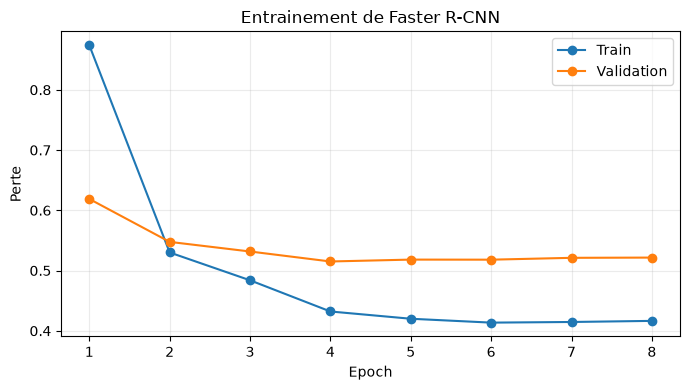

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(frcnn_history["epoch"], frcnn_history["train_loss"], marker="o", label="Train")
ax.plot(frcnn_history["epoch"], frcnn_history["val_loss"], marker="o", label="Validation")
ax.set_title("Entrainement de Faster R-CNN")
ax.set_xlabel("Epoch")
ax.set_ylabel("Perte")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

La perte de validation baisse de 0.619 a 0.515 pendant les quatre premieres epochs. Elle remonte ensuite legerement, donc le meilleur poids vient de l'epoch 4. L'entrainement complet a pris environ 5.6 minutes et aucun batch avec objets n'a ete ignore.

### 3.5 Modele principal YOLO26n-OBB

YOLO26n-OBB a deja ete ajuste pendant 20 epochs sur les tuiles de 1 024 pixels. La cellule suivante recharge le meilleur poids. Si le poids est absent, elle permet aussi de refaire l'entrainement.

In [23]:
YOLO_DATA_PATH = EXPERIMENT_DIR / "obb" / "dota_obb.yaml"
YOLO_BASE_WEIGHTS_PATH = PROJECT_DIR / "yolo26n.pt"

if not YOLO_OBB_WEIGHTS_PATH.exists():
    if not YOLO_BASE_WEIGHTS_PATH.exists():
        raise FileNotFoundError("Le poids de base yolo26n.pt est absent.")
    yolo_training_model = YOLO("yolo26n-obb.yaml").load(
        str(YOLO_BASE_WEIGHTS_PATH)
    )
    yolo_training_model.train(
        data=str(YOLO_DATA_PATH), epochs=20, imgsz=1024, batch=4,
        device=0, workers=0, seed=SEED, patience=7, close_mosaic=5,
        project=str(RUNS_DIR / "dota_experiment_v1"),
        name="tuned_obb_yolo26n_e20_img1024", exist_ok=True,
    )

yolo_obb_model = YOLO(str(YOLO_OBB_WEIGHTS_PATH))
print("Poids YOLO26n-OBB-1024 charges.")

Poids YOLO26n-OBB-1024 charges.


### 3.6 Evaluation sur la validation

Les 245 tuiles validation sont utilisees, y compris les tuiles vides. Une prediction est correcte si la classe est bonne et si l'IoU depasse le seuil demande. La mAP50 utilise IoU = 0.50 et la mAP50-95 moyenne plusieurs seuils de 0.50 a 0.95.

In [24]:
FRCNN_PREDICTIONS_PATH = FRCNN_RUN_DIR / "validation_predictions.pt"
frcnn_eval_loader = DataLoader(
    frcnn_val_dataset, batch_size=FRCNN_BATCH_SIZE, shuffle=False,
    num_workers=0, collate_fn=collate_detection_batch,
)


def predict_faster_rcnn(model, data_loader):
    predictions = []
    targets_cpu = []
    inference_seconds = 0.0
    model = model.to(DEVICE).eval()

    with torch.inference_mode():
        for images, targets in data_loader:
            device_images = [image.to(DEVICE) for image in images]
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            start_time = perf_counter()
            batch_predictions = model(device_images)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            inference_seconds += perf_counter() - start_time

            predictions.extend(
                [
                    {key: value.detach().cpu() for key, value in prediction.items()}
                    for prediction in batch_predictions
                ]
            )
            targets_cpu.extend(
                [
                    {"boxes": target["boxes"], "labels": target["labels"]}
                    for target in targets
                ]
            )

    model = model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        "predictions": predictions,
        "targets": targets_cpu,
        "inference_ms_per_image": 1000 * inference_seconds / len(predictions),
    }


if FRCNN_PREDICTIONS_PATH.exists() and not FORCE_TRAINING:
    frcnn_cache = torch.load(
        FRCNN_PREDICTIONS_PATH, map_location="cpu", weights_only=False
    )
else:
    frcnn_cache = predict_faster_rcnn(faster_rcnn_model, frcnn_eval_loader)
    torch.save(frcnn_cache, FRCNN_PREDICTIONS_PATH)

frcnn_predictions = frcnn_cache["predictions"]
frcnn_targets = frcnn_cache["targets"]
pd.DataFrame(
    {
        "Tuiles": [len(frcnn_predictions)],
        "Predictions": [sum(len(item["boxes"]) for item in frcnn_predictions)],
        "Inference ms/image": [frcnn_cache["inference_ms_per_image"]],
    }
).round(2)

,Tuiles,Predictions,Inference ms/image
0,245,63082,17.12


In [25]:
from torchvision.ops import box_iou


def match_class_predictions(predictions, targets, class_label, iou_threshold):
    score_rows = []
    true_positive_rows = []
    ground_truth_count = 0

    for prediction, target in zip(predictions, targets):
        pred_mask = prediction["labels"] == class_label
        target_mask = target["labels"] == class_label
        pred_boxes = prediction["boxes"][pred_mask]
        pred_scores = prediction["scores"][pred_mask]
        target_boxes = target["boxes"][target_mask]
        ground_truth_count += len(target_boxes)

        order = torch.argsort(pred_scores, descending=True)
        pred_boxes = pred_boxes[order]
        pred_scores = pred_scores[order]
        matched_targets = set()
        ious = box_iou(pred_boxes, target_boxes)

        for pred_index, score in enumerate(pred_scores):
            is_true_positive = 0
            if len(target_boxes) > 0:
                best_target = int(torch.argmax(ious[pred_index]).item())
                best_iou = float(ious[pred_index, best_target])
                if best_iou >= iou_threshold and best_target not in matched_targets:
                    matched_targets.add(best_target)
                    is_true_positive = 1
            score_rows.append(float(score))
            true_positive_rows.append(is_true_positive)

    return np.asarray(score_rows), np.asarray(true_positive_rows), ground_truth_count


def compute_average_precision(scores, true_positives, ground_truth_count):
    if ground_truth_count == 0:
        return np.nan
    order = np.argsort(-scores)
    true_positives = true_positives[order]
    false_positives = 1 - true_positives
    recall = np.cumsum(true_positives) / ground_truth_count
    precision = np.cumsum(true_positives) / np.maximum(
        np.cumsum(true_positives) + np.cumsum(false_positives), 1
    )
    recall_curve = np.concatenate(([0.0], recall, [1.0]))
    precision_curve = np.concatenate(([1.0], precision, [0.0]))
    precision_curve = np.flip(np.maximum.accumulate(np.flip(precision_curve)))
    recall_points = np.linspace(0, 1, 101)
    return np.trapezoid(
        np.interp(recall_points, recall_curve, precision_curve), recall_points
    )


def evaluate_faster_rcnn(predictions, targets):
    iou_thresholds = np.arange(0.50, 0.96, 0.05)
    class_rows = []
    all_scores = []
    all_true_positives = []
    all_ground_truths = 0

    for class_id, class_name in enumerate(DOTA_CLASSES):
        class_aps = []
        for iou_threshold in iou_thresholds:
            scores, true_positives, ground_truth_count = match_class_predictions(
                predictions, targets, class_id + 1, iou_threshold
            )
            class_aps.append(
                compute_average_precision(scores, true_positives, ground_truth_count)
            )
        scores, true_positives, ground_truth_count = match_class_predictions(
            predictions, targets, class_id + 1, 0.50
        )
        all_scores.extend(scores)
        all_true_positives.extend(true_positives)
        all_ground_truths += ground_truth_count
        class_rows.append(
            {
                "Modele": "Faster R-CNN", "Classe": class_name,
                "AP50": class_aps[0], "AP50-95": np.nanmean(class_aps),
            }
        )

    all_scores = np.asarray(all_scores)
    all_true_positives = np.asarray(all_true_positives)
    order = np.argsort(-all_scores)
    cumulative_tp = np.cumsum(all_true_positives[order])
    cumulative_fp = np.cumsum(1 - all_true_positives[order])
    precision_curve = cumulative_tp / np.maximum(cumulative_tp + cumulative_fp, 1)
    recall_curve = cumulative_tp / all_ground_truths
    f1_curve = 2 * precision_curve * recall_curve / np.maximum(
        precision_curve + recall_curve, 1e-12
    )
    best_index = int(np.argmax(f1_curve))
    class_table = pd.DataFrame(class_rows)
    global_row = {
        "Modele": "Faster R-CNN", "Boites": "HBB",
        "Precision": precision_curve[best_index],
        "Rappel": recall_curve[best_index], "F1": f1_curve[best_index],
        "mAP50": class_table["AP50"].mean(),
        "mAP50-95": class_table["AP50-95"].mean(),
        "Seuil": all_scores[order][best_index],
        "Inference ms/image": frcnn_cache["inference_ms_per_image"],
    }
    return global_row, class_table


frcnn_metrics, frcnn_class_metrics = evaluate_faster_rcnn(
    frcnn_predictions, frcnn_targets
)
pd.DataFrame([frcnn_metrics]).round(3)

,Modele,Boites,Precision,Rappel,F1,mAP50,mAP50-95,Seuil,Inference ms/image
0,Faster R-CNN,HBB,0.308,0.163,0.213,0.142,0.06,0.271,17.123


In [26]:
YOLO_METRICS_PATH = OUTPUT_DIR / "yolo_obb_metrics.csv"
YOLO_CLASS_METRICS_PATH = OUTPUT_DIR / "yolo_obb_class_metrics.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if YOLO_METRICS_PATH.exists() and YOLO_CLASS_METRICS_PATH.exists() and not FORCE_TRAINING:
    yolo_metrics_table = pd.read_csv(YOLO_METRICS_PATH)
    yolo_class_metrics = pd.read_csv(YOLO_CLASS_METRICS_PATH)
else:
    yolo_validation = yolo_obb_model.val(
        data=str(YOLO_DATA_PATH), split="val", imgsz=1024, batch=4,
        device=0, workers=0, conf=0.001, iou=0.7, max_det=300,
        plots=False, verbose=False,
        project=str(RUNS_DIR / "dota_experiment_v1" / "validation"),
        name="yolo_obb_1024", exist_ok=True,
    )
    metric_box = yolo_validation.box
    yolo_metrics_table = pd.DataFrame(
        [
            {
                "Modele": "YOLO26n-OBB-1024", "Boites": "OBB",
                "Precision": float(metric_box.mp),
                "Rappel": float(metric_box.mr),
                "F1": float(2 * metric_box.mp * metric_box.mr / max(metric_box.mp + metric_box.mr, 1e-12)),
                "mAP50": float(metric_box.map50),
                "mAP50-95": float(metric_box.map), "Seuil": np.nan,
                "Inference ms/image": float(yolo_validation.speed.get("inference", np.nan)),
            }
        ]
    )
    yolo_class_rows = []
    for position, class_id in enumerate(np.asarray(metric_box.ap_class_index, dtype=int)):
        yolo_class_rows.append(
            {
                "Modele": "YOLO26n-OBB-1024",
                "Classe": DOTA_CLASSES[class_id],
                "AP50": float(metric_box.ap50[position]),
                "AP50-95": float(metric_box.ap[position]),
            }
        )
    yolo_class_metrics = pd.DataFrame(yolo_class_rows)
    yolo_metrics_table.to_csv(YOLO_METRICS_PATH, index=False)
    yolo_class_metrics.to_csv(YOLO_CLASS_METRICS_PATH, index=False)

yolo_metrics_table.round(3)

,Modele,Boites,Precision,Rappel,F1,mAP50,mAP50-95,Seuil,Inference ms/image
0,YOLO26n-OBB-1024,OBB,0.572,0.291,0.386,0.272,0.185,NaN,7.928


In [27]:
model_comparison = pd.concat(
    [pd.DataFrame([frcnn_metrics]), yolo_metrics_table], ignore_index=True
)
class_metric_comparison = pd.concat(
    [frcnn_class_metrics, yolo_class_metrics], ignore_index=True
)

model_comparison.round(3)

,Modele,Boites,Precision,Rappel,F1,mAP50,mAP50-95,Seuil,Inference ms/image
0,Faster R-CNN,HBB,0.308,0.163,0.213,0.142,0.060,0.271,17.123
1,YOLO26n-OBB-1024,OBB,0.572,0.291,0.386,0.272,0.185,NaN,7.928


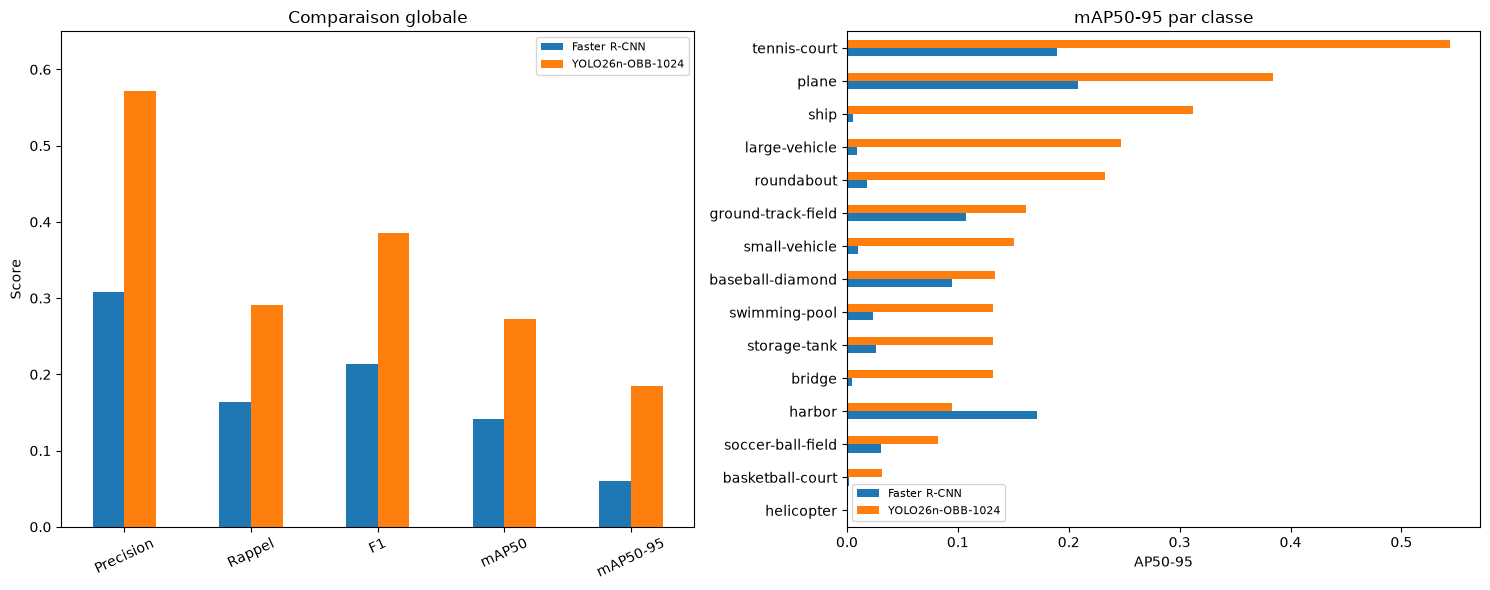

In [28]:
metric_columns = ["Precision", "Rappel", "F1", "mAP50", "mAP50-95"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
model_comparison.set_index("Modele")[metric_columns].T.plot(
    kind="bar", ax=axes[0], color=["tab:blue", "tab:orange"]
)
axes[0].set_title("Comparaison globale")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 0.65)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(fontsize=8)

class_pivot = class_metric_comparison.pivot(
    index="Classe", columns="Modele", values="AP50-95"
).sort_values("YOLO26n-OBB-1024")
class_pivot.plot(
    kind="barh", ax=axes[1], color=["tab:blue", "tab:orange"]
)
axes[1].set_title("mAP50-95 par classe")
axes[1].set_xlabel("AP50-95")
axes[1].set_ylabel("")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

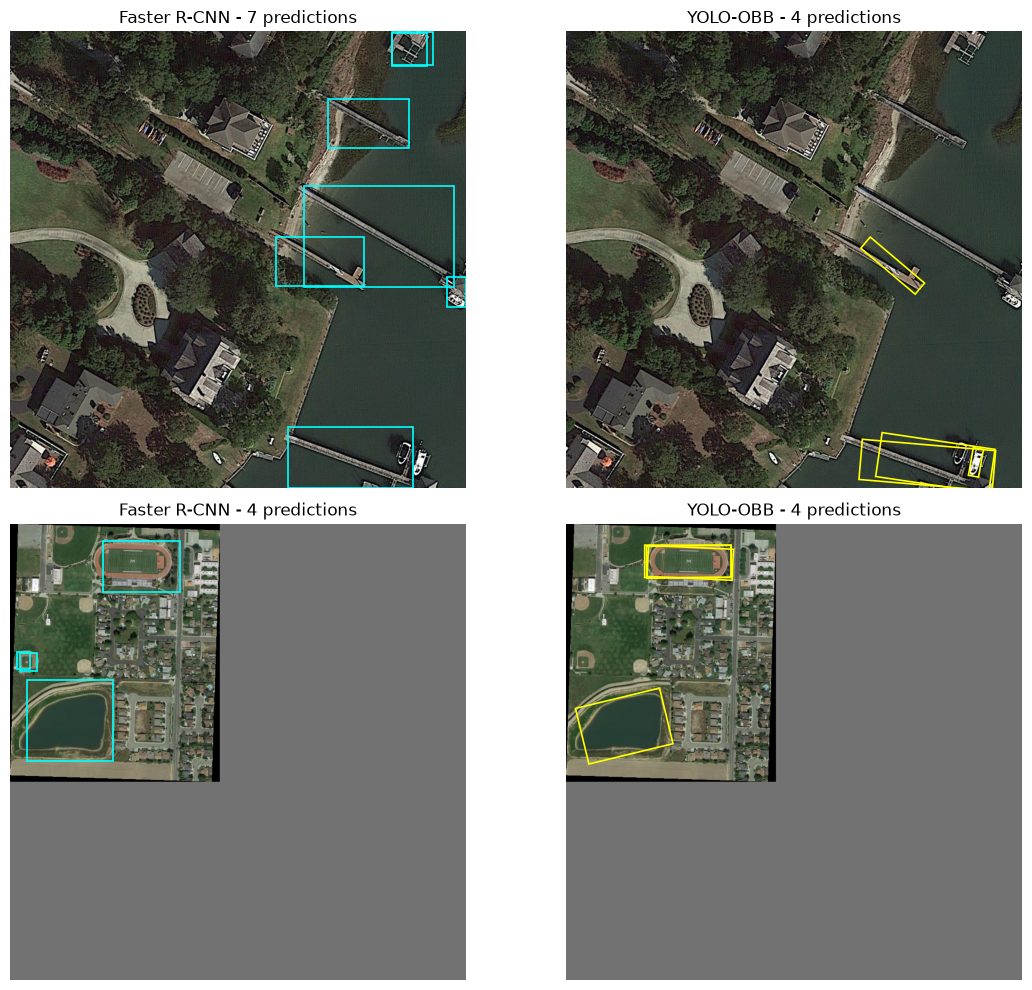

In [29]:
candidate_indices = [
    index for index, target in enumerate(frcnn_targets)
    if 5 <= len(target["boxes"]) <= 20
]
sample_eval_indices = [
    candidate_indices[len(candidate_indices) // 3],
    candidate_indices[2 * len(candidate_indices) // 3],
]
sample_paths = [frcnn_val_dataset.image_paths[index] for index in sample_eval_indices]
yolo_visual_results = yolo_obb_model.predict(
    source=[str(path) for path in sample_paths], imgsz=1024, conf=0.25,
    iou=0.7, max_det=100, device=0, verbose=False,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row_index, (sample_index, image_path, yolo_result) in enumerate(
    zip(sample_eval_indices, sample_paths, yolo_visual_results)
):
    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB")
        axes[row_index, 0].imshow(rgb_image)
        axes[row_index, 1].imshow(rgb_image)

    frcnn_prediction = frcnn_predictions[sample_index]
    frcnn_mask = frcnn_prediction["scores"] >= 0.25
    for x_min, y_min, x_max, y_max in frcnn_prediction["boxes"][frcnn_mask]:
        axes[row_index, 0].add_patch(
            plt.Rectangle(
                (float(x_min), float(y_min)), float(x_max - x_min),
                float(y_max - y_min), fill=False, color="cyan", linewidth=1.2,
            )
        )

    yolo_count = 0
    if yolo_result.obb is not None:
        for polygon in yolo_result.obb.xyxyxyxy.cpu().numpy():
            axes[row_index, 1].add_patch(
                plt.Polygon(polygon, fill=False, color="yellow", linewidth=1.2)
            )
        yolo_count = len(yolo_result.obb)

    axes[row_index, 0].set_title(
        f"Faster R-CNN - {int(frcnn_mask.sum())} predictions"
    )
    axes[row_index, 1].set_title(f"YOLO-OBB - {yolo_count} predictions")
    axes[row_index, 0].axis("off")
    axes[row_index, 1].axis("off")

fig.tight_layout()
plt.show()

### 3.7 Interpretation

YOLO26n-OBB-1024 donne les meilleurs resultats : sa mAP50-95 atteint 0.185 contre 0.060 pour Faster R-CNN. Il a aussi un meilleur F1 (0.386 contre 0.213) et il est plus rapide (7.9 ms contre 17.1 ms par image). Pour la suite, YOLO est donc le modele principal.

### 3.8 Limites

Les petits objets et les classes rares restent difficiles. Faster R-CNN perd l'angle des objets et utilise une entree plus petite. YOLO est entraine plus longtemps et avec des augmentations, donc cette comparaison est pratique mais elle ne mesure pas uniquement l'effet des boites orientees. Ces resultats sont predictifs et ne donnent pas encore un effet causal.

## 4. Formulation de la question causale

### 4.1 Question, traitement et outcome

La partie predictive mesure les erreurs de YOLO. La partie causale pose une autre question : **quel est l'effet d'etre un objet tres petit sur la probabilite d'une detection correcte ?**

- traitement D = 1 : l'objet appartient au premier quartile des aires relatives de tuile du train ;
- outcome Y = 1 : YOLO trouve une boite de meme classe, avec une confiance au moins egale a 0.25 et une IoU orientee au moins egale a 0.50 ;
- population : objets originaux uniques du sous-ensemble validation.

### 4.2 Population d'analyse

Le seuil du traitement est calcule uniquement avec le train. Le matching objet-prediction de la question 3 est ensuite rattache aux objets de validation.

In [30]:
CAUSAL_OBJECTS_PATH = OUTPUT_DIR / "causal_object_table.csv"
if not CAUSAL_OBJECTS_PATH.exists():
    raise FileNotFoundError("La table de matching objet-prediction est absente.")

train_mask = analysis_objects["split"].eq("train")
train_relative_area_tile = (
    analysis_objects.loc[train_mask, "clipped_polygon_area_px"]
    / analysis_objects.loc[train_mask, "tile_size"].pow(2)
)
SMALL_AREA_THRESHOLD = train_relative_area_tile.quantile(0.25)

match_columns = [
    "object_id", "relative_area_tile", "matched_iou", "matched_confidence"
]
matched_validation = pd.read_csv(
    CAUSAL_OBJECTS_PATH, usecols=match_columns
)
expected_ids = set(
    analysis_table.loc[analysis_table["split"].eq("val"), "object_id"]
)
if set(matched_validation["object_id"]) != expected_ids:
    raise ValueError("Les objets du cache causal ne correspondent pas a la validation.")

causal_data = (
    analysis_table.loc[analysis_table["split"].eq("val")]
    .drop(columns="detection_correcte")
    .merge(matched_validation, on="object_id", how="left", validate="one_to_one")
)
causal_data["very_small"] = (
    causal_data["relative_area_tile"] <= SMALL_AREA_THRESHOLD
).astype(int)
causal_data["detection_correcte"] = (
    causal_data["matched_confidence"].ge(0.25)
    & causal_data["matched_iou"].ge(0.50)
).astype(int)

causal_formulation = pd.DataFrame(
    [
        {
            "Element": "Traitement D",
            "Definition": f"Aire relative de tuile <= {SMALL_AREA_THRESHOLD:.6f}",
        },
        {
            "Element": "Outcome Y",
            "Definition": "Meme classe, confiance >= 0.25 et IoU OBB >= 0.50",
        },
        {
            "Element": "Population",
            "Definition": "Objets uniques de validation",
        },
    ]
)
causal_counts = pd.DataFrame(
    {
        "Objets": [len(causal_data)],
        "Images source": [causal_data["image_id"].nunique()],
        "Tres petits": [int(causal_data["very_small"].sum())],
        "Autres": [int(causal_data["very_small"].eq(0).sum())],
        "Detections correctes": [int(causal_data["detection_correcte"].sum())],
    }
)

display(causal_formulation)
causal_counts

,Element,Definition
0,Traitement D,Aire relative de tuile <= 0.000504
1,Outcome Y,"Meme classe, confiance >= 0.25 et IoU OBB >= 0.50"
2,Population,Objets uniques de validation


,Objets,Images source,Tres petits,Autres,Detections correctes
0,1646,53,623,1023,716


Le seuil vaut environ 0.000504 de la surface d'une tuile. La population contient 1 646 objets venant de 53 images : 623 objets traites et 1 023 controles. Chaque objet original apparait une seule fois. Le matching impose deja la meme classe ; une prediction trop peu confiante, trop eloignee ou absente donne Y = 0.

### 4.3 DAG et variables d'ajustement

Le DAG suivant resume les relations supposees avant l'estimation.

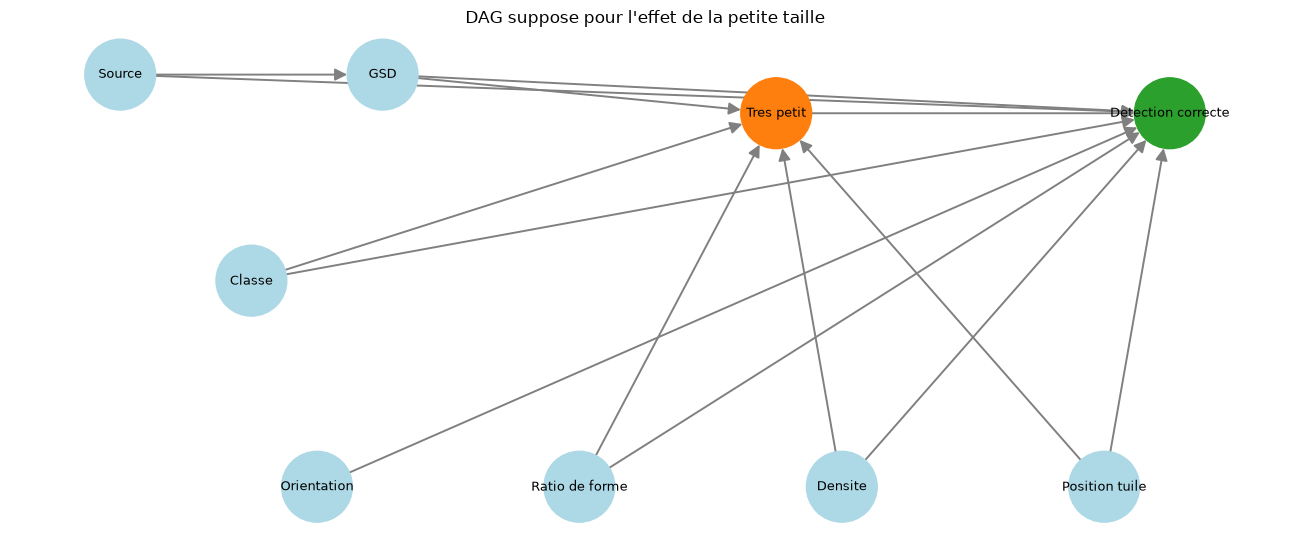

In [31]:
import networkx as nx

dag_edges = [
    ("Source", "GSD"),
    ("Source", "Detection correcte"),
    ("GSD", "Tres petit"),
    ("GSD", "Detection correcte"),
    ("Classe", "Tres petit"),
    ("Classe", "Detection correcte"),
    ("Orientation", "Detection correcte"),
    ("Ratio de forme", "Tres petit"),
    ("Ratio de forme", "Detection correcte"),
    ("Densite", "Tres petit"),
    ("Densite", "Detection correcte"),
    ("Position tuile", "Tres petit"),
    ("Position tuile", "Detection correcte"),
    ("Tres petit", "Detection correcte"),
]
causal_dag = nx.DiGraph(dag_edges)
dag_positions = {
    "Source": (0.0, 2.8),
    "GSD": (2.0, 2.8),
    "Classe": (1.0, 1.2),
    "Orientation": (1.5, -0.4),
    "Ratio de forme": (3.5, -0.4),
    "Densite": (5.5, -0.4),
    "Position tuile": (7.5, -0.4),
    "Tres petit": (5.0, 2.5),
    "Detection correcte": (8.0, 2.5),
}
node_colors = [
    "tab:orange" if node == "Tres petit"
    else "tab:green" if node == "Detection correcte"
    else "lightblue"
    for node in causal_dag.nodes
]

fig, ax = plt.subplots(figsize=(13, 5.5))
nx.draw_networkx(
    causal_dag,
    pos=dag_positions,
    node_color=node_colors,
    node_size=2600,
    font_size=9,
    arrows=True,
    arrowsize=18,
    width=1.4,
    edge_color="gray",
    ax=ax,
)
ax.set_title("DAG suppose pour l'effet de la petite taille")
ax.axis("off")
fig.tight_layout()
plt.show()

Les fleches qui arrivent a la fois vers le traitement et l'outcome representent des chemins de confusion possibles. La classe, le GSD, la source, l'orientation, le ratio de forme, la densite et la position dans la tuile seront utilises pour rendre les groupes plus comparables. La confiance, l'IoU et la fraction conservee ne sont pas des variables d'ajustement : elles definissent le resultat ou peuvent venir apres la selection de la tuile.

### 4.4 Estimand et hypotheses

L'estimand est l'ATE : la difference moyenne E[Y(1) - Y(0)] de probabilite de detection correcte entre l'etat tres petit et l'etat controle.

Son interpretation causale demande plusieurs hypotheses :

1. apres ajustement, il ne reste pas de facteur important non observe qui explique a la fois la taille et la detection ;
2. chaque profil contient des objets petits et non petits comparables ;
3. la definition du traitement et de l'outcome reste la meme pour tous les objets ;
4. les images source train et validation restent separees ;
5. la dependance entre objets d'une meme image est prise en compte pendant l'estimation.

La taille n'est pas randomisee et elle est difficile a manipuler directement. Le resultat restera donc un effet observationnel sous hypotheses, pas la preuve d'une experience controlee.

## 5. Estimation causale et heterogeneite

### 5.1 Methodes comparees

Quatre estimations sont comparees :

- difference brute entre les deux groupes ;
- g-computation a partir des outcomes predits sous D = 0 et D = 1 ;
- IPW, qui pondere les objets avec leur score de propension ;
- AIPW, qui combine les deux modeles et sert d'estimation ajustee principale.

Les probabilites de traitement et d'outcome ont ete produites par cross-fitting groupe par image dans le pipeline complet. Cette version compacte recharge ces predictions par objet, recalcule les quatre effets et reechantillonne les images source pour les intervalles.

In [32]:
scored_columns = [
    "object_id", "propensity_score", "predicted_outcome_control",
    "predicted_outcome_treated", "aipw_score", "tile_object_count",
    "center_margin_normalized",
]
cross_fitted_scores = pd.read_csv(
    CAUSAL_OBJECTS_PATH, usecols=scored_columns
)
causal_analysis = causal_data.merge(
    cross_fitted_scores, on="object_id", how="left", validate="one_to_one"
)

treatment = causal_analysis["very_small"].to_numpy(dtype=int)
outcome = causal_analysis["detection_correcte"].to_numpy(dtype=int)
propensity = np.clip(
    causal_analysis["propensity_score"].to_numpy(dtype=float), 0.05, 0.95
)
mu_control = causal_analysis["predicted_outcome_control"].to_numpy(dtype=float)
mu_treated = causal_analysis["predicted_outcome_treated"].to_numpy(dtype=float)

raw_score = np.where(
    treatment == 1,
    outcome / treatment.mean(),
    -outcome / (1 - treatment).mean(),
)
g_computation_score = mu_treated - mu_control
ipw_score = (
    treatment * outcome / propensity
    - (1 - treatment) * outcome / (1 - propensity)
)
aipw_score = (
    mu_treated - mu_control
    + treatment * (outcome - mu_treated) / propensity
    - (1 - treatment) * (outcome - mu_control) / (1 - propensity)
)
if not np.allclose(aipw_score, causal_analysis["aipw_score"]):
    raise ValueError("Le recalcul AIPW ne correspond pas au cache.")
causal_analysis["aipw_score_recalculated"] = aipw_score


def cluster_bootstrap_interval(values, groups, seed, repetitions=1000):
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)
    unique_groups = np.unique(groups)
    positions = {
        group: np.flatnonzero(groups == group) for group in unique_groups
    }
    rng = np.random.default_rng(seed)
    means = np.empty(repetitions)
    for repetition in range(repetitions):
        sampled_groups = rng.choice(
            unique_groups, size=len(unique_groups), replace=True
        )
        sampled_positions = np.concatenate(
            [positions[group] for group in sampled_groups]
        )
        means[repetition] = values[sampled_positions].mean()
    return np.quantile(means, [0.025, 0.975])


score_map = {
    "Difference brute": raw_score,
    "G-computation": g_computation_score,
    "IPW": ipw_score,
    "AIPW": aipw_score,
}
groups = causal_analysis["image_id"].astype(str).to_numpy()
estimate_rows = []
for method_index, (method, scores) in enumerate(score_map.items()):
    lower, upper = cluster_bootstrap_interval(
        scores, groups, seed=SEED + method_index
    )
    estimate_rows.append(
        {
            "Methode": method,
            "Effet": scores.mean(),
            "IC_inferieur": lower,
            "IC_superieur": upper,
        }
    )
causal_estimates = pd.DataFrame(estimate_rows)

observed_rates = (
    causal_analysis.groupby("very_small")["detection_correcte"]
    .agg(Objets="size", Taux_detection="mean")
    .rename(index={0: "Controle", 1: "Tres petit"})
)
display(observed_rates.round(3))
causal_estimates.round(3)

,Objets,Taux_detection
very_small,,
Controle,1023,0.513
Tres petit,623,0.307


,Methode,Effet,IC_inferieur,IC_superieur
0,Difference brute,-0.207,-0.52,0.052
1,G-computation,-0.170,-0.26,-0.096
2,IPW,-0.620,-0.86,-0.352
3,AIPW,-0.368,-0.53,-0.166


Le taux observe est de 30.7 % chez les objets tres petits contre 51.3 % chez les controles, soit une difference brute de -20.7 points. Apres ajustement, l'AIPW estime un effet de -0.368, avec un IC 95 % groupe [-0.530 ; -0.166]. Sous les hypotheses de la question 4, cela correspond a une baisse moyenne de 36.8 points de probabilite de detection correcte.

L'AIPW combine le modele de propension et le modele d'outcome. Sous les autres hypotheses, il est dit doublement robuste car un des deux modeles peut compenser une mauvaise specification de l'autre. Cela ne corrige toutefois ni un confounder non observe ni une mauvaise definition du traitement. L'ecart entre g-computation, IPW et AIPW montre aussi que l'amplitude exacte reste sensible a la methode.

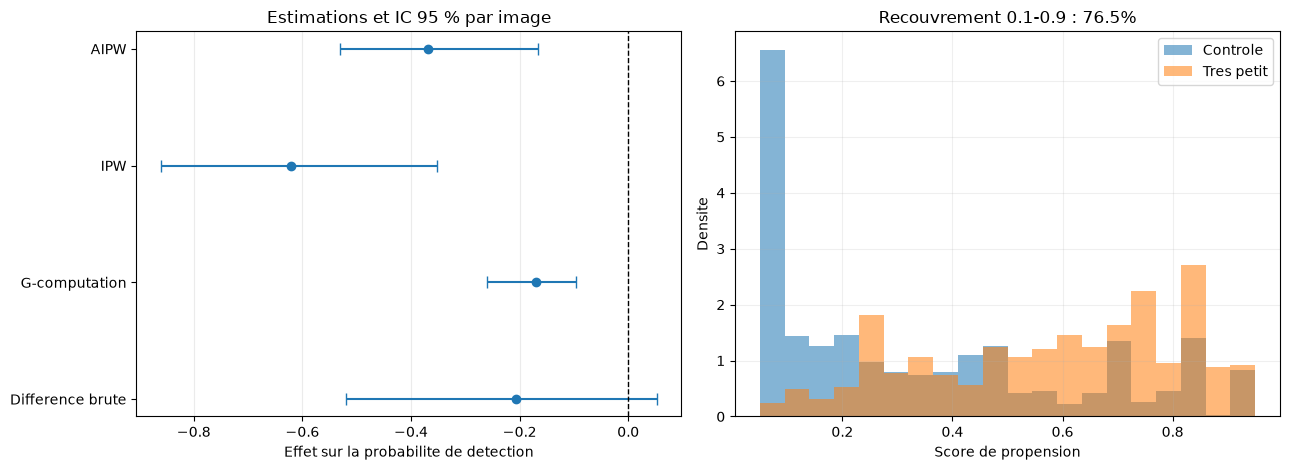

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

positions = np.arange(len(causal_estimates))
effects = causal_estimates["Effet"].to_numpy()
lower_errors = effects - causal_estimates["IC_inferieur"].to_numpy()
upper_errors = causal_estimates["IC_superieur"].to_numpy() - effects
axes[0].errorbar(
    effects, positions, xerr=[lower_errors, upper_errors],
    fmt="o", color="tab:blue", capsize=4,
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_yticks(positions, causal_estimates["Methode"])
axes[0].set_xlabel("Effet sur la probabilite de detection")
axes[0].set_title("Estimations et IC 95 % par image")
axes[0].grid(axis="x", alpha=0.25)

for level, label, color in [
    (0, "Controle", "tab:blue"),
    (1, "Tres petit", "tab:orange"),
]:
    axes[1].hist(
        propensity[treatment == level], bins=20, alpha=0.55,
        density=True, label=label, color=color,
    )
overlap_rate = ((propensity >= 0.1) & (propensity <= 0.9)).mean()
axes[1].set_xlabel("Score de propension")
axes[1].set_ylabel("Densite")
axes[1].set_title(f"Recouvrement 0.1-0.9 : {overlap_rate:.1%}")
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

Environ 76.5 % des objets ont une propension entre 0.1 et 0.9. Le recouvrement existe, mais les valeurs proches des bornes montrent que certains profils sont difficiles a comparer. Les scores sont donc limites a [0.05, 0.95] pour eviter des poids extremes.

### 5.2 Analyse de sensibilite

Les specifications suivantes changent le seuil d'IoU, le clipping de propension ou la graine des modeles.

In [34]:
sensitivity_path = OUTPUT_DIR / "causal_sensitivity.csv"
if not sensitivity_path.exists():
    raise FileNotFoundError("Le tableau de sensibilite est absent.")

causal_sensitivity = pd.read_csv(sensitivity_path).rename(
    columns={
        "specification": "Specification",
        "effect": "Effet",
        "ci_lower": "IC_inferieur",
        "ci_upper": "IC_superieur",
    }
)
causal_sensitivity[
    ["Specification", "Effet", "IC_inferieur", "IC_superieur"]
].round(3)

,Specification,Effet,IC_inferieur,IC_superieur
0,IoU >= 0.40,-0.374,-0.518,-0.190
1,IoU >= 0.50,-0.368,-0.519,-0.183
2,IoU >= 0.60,-0.332,-0.480,-0.141
3,Propension clip 0.02,-0.274,-0.507,0.085
4,Propension clip 0.10,-0.388,-0.504,-0.246
5,Graine nuisances 7,-0.370,-0.535,-0.155
6,Graine nuisances 99,-0.366,-0.522,-0.177


Toutes les estimations ponctuelles restent negatives. Pour le clipping 0.02, l'intervalle traverse toutefois zero. Le leger ecart entre l'IC de la ligne IoU 0.50 et l'IC principal vient d'un bootstrap de sensibilite relance separement. Le signe est donc assez stable dans les tests realises, mais la precision depend du recouvrement et aucun test ne supprime le risque de confusion non observee.

### 5.3 Arbre causal peu profond

L'arbre cherche si l'effet AIPW change selon les caracteristiques des objets. Les images sont separees en deux moities : une pour choisir la division et une autre pour estimer les effets des feuilles. La profondeur est limitee a un pour garder un resultat lisible et reduire le surapprentissage.

|--- Densite tuile <= 16.500
|   |--- value: [-0.193]
|--- Densite tuile >  16.500
|   |--- value: [-0.608]



,Sous_groupe,Objets,Images,Traites,Controles,Effet,IC_inferieur,IC_superieur
0,Densite tuile <= 16.5,296,20,41,255,-0.131,-0.640,0.474
1,Densite tuile > 16.5,795,12,370,425,-0.457,-0.646,-0.221


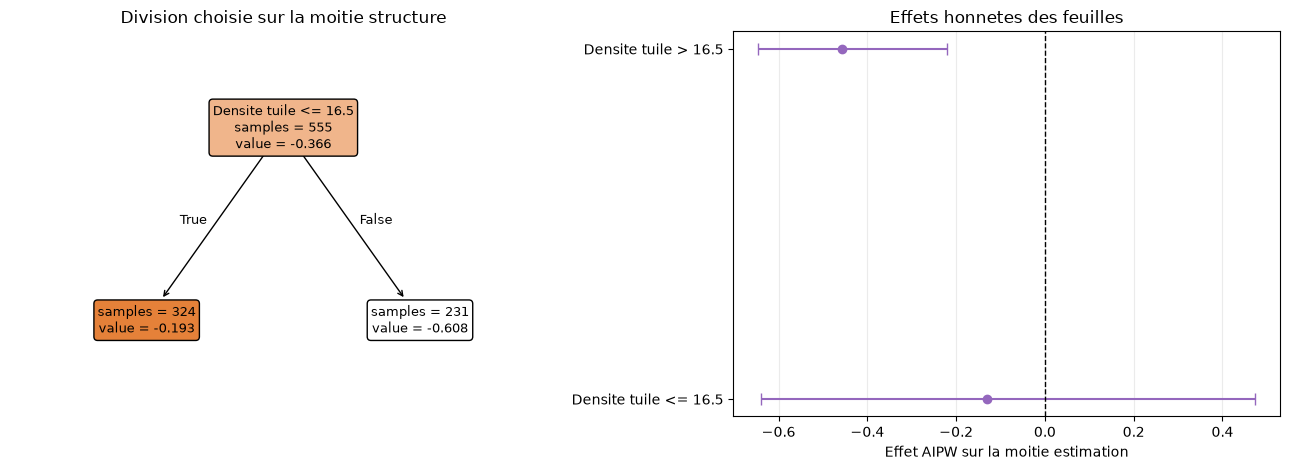

In [35]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

tree_features = [
    "orientation_abs_deg", "log_aspect_ratio", "tile_object_count",
    "gsd", "center_margin_normalized",
]
tree_feature_labels = [
    "Orientation", "Log ratio", "Densite tuile", "GSD", "Marge centre",
]
tree_splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.5, random_state=SEED
)
structure_indices, estimation_indices = next(
    tree_splitter.split(causal_analysis, groups=causal_analysis["image_id"])
)
tree_medians = causal_analysis.loc[structure_indices, tree_features].median()
structure_features = causal_analysis.loc[
    structure_indices, tree_features
].fillna(tree_medians)
estimation_features = causal_analysis.loc[
    estimation_indices, tree_features
].fillna(tree_medians)

causal_tree = DecisionTreeRegressor(
    max_depth=1, min_samples_leaf=200, random_state=SEED
)
causal_tree.fit(
    structure_features,
    causal_analysis.loc[structure_indices, "aipw_score_recalculated"],
)
tree_rules = export_text(
    causal_tree, feature_names=tree_feature_labels, decimals=3
)

estimation_table = causal_analysis.loc[estimation_indices].copy()
estimation_table["leaf_id"] = causal_tree.apply(estimation_features)
root_feature_index = causal_tree.tree_.feature[0]
root_feature_label = tree_feature_labels[root_feature_index]
root_threshold = causal_tree.tree_.threshold[0]
leaf_labels = {
    causal_tree.tree_.children_left[0]:
        f"{root_feature_label} <= {root_threshold:.1f}",
    causal_tree.tree_.children_right[0]:
        f"{root_feature_label} > {root_threshold:.1f}",
}

subgroup_rows = []
for leaf_id, subgroup in estimation_table.groupby("leaf_id"):
    lower, upper = cluster_bootstrap_interval(
        subgroup["aipw_score_recalculated"],
        subgroup["image_id"].astype(str),
        seed=SEED + int(leaf_id),
        repetitions=500,
    )
    subgroup_rows.append(
        {
            "Sous_groupe": leaf_labels[int(leaf_id)],
            "Objets": len(subgroup),
            "Images": subgroup["image_id"].nunique(),
            "Traites": int(subgroup["very_small"].sum()),
            "Controles": int(subgroup["very_small"].eq(0).sum()),
            "Effet": subgroup["aipw_score_recalculated"].mean(),
            "IC_inferieur": lower,
            "IC_superieur": upper,
        }
    )
causal_tree_subgroups = pd.DataFrame(subgroup_rows)

print(tree_rules)
display(causal_tree_subgroups.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_tree(
    causal_tree, feature_names=tree_feature_labels, filled=True,
    rounded=True, impurity=False, precision=3, ax=axes[0], fontsize=9,
)
axes[0].set_title("Division choisie sur la moitie structure")

tree_positions = np.arange(len(causal_tree_subgroups))
tree_effects = causal_tree_subgroups["Effet"].to_numpy()
tree_lower = tree_effects - causal_tree_subgroups["IC_inferieur"].to_numpy()
tree_upper = causal_tree_subgroups["IC_superieur"].to_numpy() - tree_effects
axes[1].errorbar(
    tree_effects, tree_positions, xerr=[tree_lower, tree_upper],
    fmt="o", color="tab:purple", capsize=4,
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_yticks(
    tree_positions, causal_tree_subgroups["Sous_groupe"]
)
axes[1].set_xlabel("Effet AIPW sur la moitie estimation")
axes[1].set_title("Effets honnetes des feuilles")
axes[1].grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

L'arbre choisit une seule division a 16.5 objets par tuile. Dans les tuiles les plus denses, l'effet estime est plus negatif : -0.457, avec un IC 95 % [-0.646 ; -0.221]. Dans les tuiles moins denses, l'effet vaut -0.131 et son intervalle traverse zero.

Ce resultat suggere que les petits objets sont encore plus difficiles dans les scenes chargees. Il reste exploratoire : la feuille dense ne contient que 12 images et la division ne prouve pas que la densite cause cette difference. Le bilan de la question 5 est donc un effet moyen negatif, mais dont l'amplitude et l'heterogeneite dependent des hypotheses, du recouvrement et du sous-ensemble.

## 6. Interpretation generale, conclusion et limites

### 6.1 Synthese des resultats

Les deux volets repondent a des questions differentes. Les scores predictifs comparent la qualite des detecteurs, tandis que l'effet causal estime le changement de probabilite de detection associe au traitement defini. Leurs valeurs ne doivent donc pas etre comparees directement.

In [36]:
frcnn_summary_row = model_comparison.loc[
    model_comparison["Modele"].eq("Faster R-CNN")
].iloc[0]
yolo_summary_row = model_comparison.loc[
    model_comparison["Modele"].eq("YOLO26n-OBB-1024")
].iloc[0]
aipw_summary_row = causal_estimates.loc[
    causal_estimates["Methode"].eq("AIPW")
].iloc[0]
dense_summary_row = causal_tree_subgroups.loc[
    causal_tree_subgroups["Sous_groupe"].str.contains(">", regex=False)
].iloc[0]

final_summary = pd.DataFrame(
    [
        {
            "Volet": "Prediction",
            "Resultat": "Faster R-CNN HBB",
            "Valeur": f"mAP50-95 = {frcnn_summary_row['mAP50-95']:.3f}",
            "Lecture": "Baseline horizontale",
        },
        {
            "Volet": "Prediction",
            "Resultat": "YOLO26n-OBB-1024",
            "Valeur": f"mAP50-95 = {yolo_summary_row['mAP50-95']:.3f}",
            "Lecture": "Modele principal",
        },
        {
            "Volet": "Causalite",
            "Resultat": "Effet AIPW petite taille",
            "Valeur": (
                f"{aipw_summary_row['Effet']:.3f} "
                f"[{aipw_summary_row['IC_inferieur']:.3f}; "
                f"{aipw_summary_row['IC_superieur']:.3f}]"
            ),
            "Lecture": "Effet moyen ajuste principal",
        },
        {
            "Volet": "Heterogeneite",
            "Resultat": "Tuiles de densite > 16.5",
            "Valeur": f"Effet = {dense_summary_row['Effet']:.3f}",
            "Lecture": "Sous-groupe exploratoire",
        },
    ]
)
final_summary

,Volet,Resultat,Valeur,Lecture
0,Prediction,Faster R-CNN HBB,mAP50-95 = 0.060,Baseline horizontale
1,Prediction,YOLO26n-OBB-1024,mAP50-95 = 0.185,Modele principal
2,Causalite,Effet AIPW petite taille,-0.368 [-0.530; -0.166],Effet moyen ajuste principal
3,Heterogeneite,Tuiles de densite > 16.5,Effet = -0.457,Sous-groupe exploratoire


### 6.2 Interpretation predictive

YOLO26n-OBB-1024 est le meilleur modele de cette experience. Sa mAP50-95 atteint 0.185 contre 0.060 pour Faster R-CNN, avec un meilleur F1 et un temps d'inference plus court. Les boites orientees sont adaptees aux objets DOTA, mais cette comparaison ne mesure pas leur effet isole : les architectures, les tailles d'entree, les augmentations et les durees d'entrainement different aussi.

Les scores restent modestes, surtout pour les petits objets et les classes rares. Le resultat principal est donc que YOLO-OBB est le meilleur choix parmi les configurations testees, pas qu'il resout completement la detection sur DOTA.

### 6.3 Interpretation causale

Les objets tres petits ont une probabilite de detection plus faible. L'AIPW donne un effet moyen de -0.368 et les analyses de sensibilite gardent un signe negatif. Cependant, la taille n'est pas randomisee. Cette interpretation depend de l'ajustement, du recouvrement, des variables observees et de la definition operationnelle du traitement.

L'arbre suggere un effet plus negatif dans les tuiles denses. Cette heterogeneite aide a formuler une hypothese sur les scenes chargees, mais elle ne constitue pas une nouvelle preuve causale.

### 6.4 Limites principales

1. l'experience utilise un sous-ensemble stratifie de DOTA et non toutes les images ;
2. la comparaison Faster R-CNN contre YOLO ne controle pas un seul facteur a la fois ;
3. le test DOTA ne fournit pas d'annotations locales, donc les scores finaux viennent de la validation ;
4. les classes sont desequilibrees et certaines ont peu d'exemples ;
5. l'analyse causale porte sur 53 images et peut manquer des confounders comme l'occlusion ou la qualite visuelle ;
6. les seuils de confiance, d'IoU et de propension influencent les resultats ;
7. le bootstrap reechantillonne les images sans reentrainer tous les modeles de nuisance.

### 6.5 Ameliorations possibles

- entrainer sur davantage d'images source ou sur DOTA complet ;
- comparer HBB et OBB avec la meme famille de modele, la meme resolution et le meme budget ;
- augmenter le nombre d'epochs et regler les hyperparametres avec une validation separee ;
- analyser et calibrer les erreurs par classe, taille et type de scene ;
- ajouter des variables sur l'occlusion, le contraste ou la qualite des images ;
- repeter l'analyse causale sur plusieurs sous-ensembles et refaire les modeles dans chaque bootstrap.

### 6.6 Qualite et reproductibilite

La derniere cellule verifie les elements indispensables avant de remettre ou presenter le notebook.

In [37]:
classes_per_split = object_manifest.groupby("split")["class_name"].nunique()
expected_models = {"Faster R-CNN", "YOLO26n-OBB-1024"}
final_checks = pd.DataFrame(
    [
        {
            "Controle": "Dossiers DOTA presents",
            "Valide": all(path.exists() for path in data_paths.values()),
        },
        {
            "Controle": "Images source train et validation separees",
            "Valide": len(source_overlap) == 0,
        },
        {
            "Controle": "15 classes dans les deux ensembles",
            "Valide": bool(
                classes_per_split.reindex(["train", "val"]).eq(15).all()
            ),
        },
        {
            "Controle": "Poids des deux modeles presents",
            "Valide": FRCNN_WEIGHTS_PATH.exists() and YOLO_OBB_WEIGHTS_PATH.exists(),
        },
        {
            "Controle": "245 tuiles de validation evaluees",
            "Valide": len(frcnn_predictions) == 245,
        },
        {
            "Controle": "Deux modeles dans la comparaison",
            "Valide": set(model_comparison["Modele"]) == expected_models,
        },
        {
            "Controle": "1 646 objets causaux uniques",
            "Valide": (
                len(causal_analysis) == 1646
                and causal_analysis["object_id"].is_unique
            ),
        },
        {
            "Controle": "Estimations causales completes",
            "Valide": bool(
                causal_estimates[
                    ["Effet", "IC_inferieur", "IC_superieur"]
                ].notna().all().all()
            ),
        },
    ]
)
if not final_checks["Valide"].all():
    raise AssertionError("Un controle final du notebook a echoue.")

final_checks

,Controle,Valide
0,Dossiers DOTA presents,True
1,Images source train et validation separees,True
2,15 classes dans les deux ensembles,True
3,Poids des deux modeles presents,True
4,245 tuiles de validation evaluees,True
5,Deux modeles dans la comparaison,True
6,1 646 objets causaux uniques,True
7,Estimations causales completes,True


### 6.7 Conclusion finale

Ce projet construit un pipeline complet, depuis les annotations DOTA jusqu'a la comparaison de detecteurs et a l'analyse causale de leurs erreurs. Parmi les modeles testes, YOLO26n-OBB-1024 est le plus performant. L'analyse causale suggere ensuite que la tres petite taille reduit fortement la probabilite de detection correcte, surtout dans les tuiles denses.

La conclusion reste volontairement prudente : le resultat predictif est mesure sur le sous-ensemble validation et le resultat causal depend d'hypotheses observationnelles. L'apport principal du projet est donc une chaine reproductible qui distingue clairement performance predictive, analyse des erreurs et interpretation causale.